# Bài tập lớn: Phân tích và dự đoán bệnh tim mạch
**Nhóm 14**

## I. Định nghĩa bài toán

Bệnh tim mạch là nguyên nhân tử vong hàng đầu trên thế giới. Việc
chẩn đoán sớm dựa trên các chỉ số lâm sàng giúp can thiệp kịp thời
và giảm nguy cơ tử vong đáng kể.

Notebook này thực hiện toàn bộ quy trình phân tích và xây dựng mô
hình phân loại bệnh tim (có bệnh / không có bệnh) từ dữ liệu lâm sàng
của 920 bệnh nhân từ 4 bệnh viện: Cleveland, Hungary, Switzerland
và VA Long Beach.

**Dataset:** UCI Heart Disease Repository

**Bài toán:** Dự đoán bệnh nhân có bệnh tim hay không

**Loại:** Binary Classification (Phân loại bệnh hoặc không bệnh)

**Metrics:** Recall (Ưu tiên) — hạn chế bỏ sót bệnh nhân có bệnh, và Precision cũng phải hợp lý để tránh lãng phí tài nguyên bệnh viện khi bắt nhầm người khoẻ mạnh

**MỤC LỤC**
- [I. Định nghĩa bài toán]()
- [II. Exploratory Data Analysis (EDA)]()
- [III. Preprocessor]()
- [IV. Modeling]()
- [V. Evaluation]()
- [VI. Model Persistence]()
- [VII. Tổng Kết & Hướng Phát Triển]()

**Import các thư viện cần thiết**

In [1]:
# Standard Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from datetime import datetime
from pathlib import Path

# Sklearn Library
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,

)

# Wandb Library
import wandb

# Joblib Library
import joblib as jb

**Một số cấu hình cần thiết**

In [2]:
# Khai báo hằng số
RANDOM_STATE = 42
THRESHOLD = 0.4

In [3]:
# Cố định random state để kết quả mỗi lần chạy là như nhau
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = '42'

In [4]:
# Cấu hình của Wandb
WANDB_PROJECT = "heart-disease-classification"
WANDB_ENTITY  = "phat-05"

In [5]:
# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette('Set2')

## II. Exploratory Data Analysis (EDA)

### 1. Load data

In [6]:
# Định nghĩa đường dẫn tới file dataset
dataset_path = Path().resolve().parent / "data/dataset.csv"

# Load data
df = pd.read_csv(dataset_path)

### 2. Data Overview

Hiển thị tổng quan về các thông tin cơ bản của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...

In [7]:
# Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

- Dataset có 920 dòng và 16 cột.


In [8]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [9]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê numerical:")
display(df.describe())

print("- Các thông tin thống kê categorical:")
display(df.describe(include=['object', 'string']))

- Các thông tin thống kê numerical:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- Các thông tin thống kê categorical:


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [10]:
# Xem 5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Như vậy:** Ta xác định được các cộc numerical và các cột categorical

In [11]:
# Các cột numerical
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Các cột categorical
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

**Chuẩn hoá biến mục tiêu**

Hiện tại biến mục tiêu trong dataset gốc đang có giá trị từ 0 đến 4, trong đó 0 = không bệnh và 1 đến 4 biểu thị mức độ bệnh.

Tuy nhiên, bài toán đã xác định loại bài toán là **Binary Classification** - phân loại nhị phân (có bệnh/không bệnh).

Vì vậy, nhóm quyết định thêm cột target để làm biến mục tiêu: (0: num = 0; 1: num > 0)

In [12]:
# Dùng hàm astype để convert tất cả dữ liệu trong cột từ bool thành int
df['target'] = (df['num'] > 0).astype(int)

#Hiển thị dữ liệu đã thêm target
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


### 3. Missing Value Analysis

**Phân tích giá trị thiếu (Missing Value Analysis)** nhằm xác định sự tồn tại và mức độ thiếu hụt dữ liệu trong tập dữ liệu. Các giá trị thiếu có thể phát sinh do lỗi thu thập, nhập liệu hoặc các yếu tố khách quan trong quá trình ghi nhận dữ liệu.

Trong nghiên cứu này, các biến lâm sàng có thể chứa giá trị thiếu, ảnh hưởng đến tính toàn vẹn và độ tin cậy của dữ liệu. Nếu không được xử lý phù hợp, các giá trị thiếu có thể gây sai lệch trong phân tích thống kê và làm giảm hiệu suất của mô hình machine learning.

Do đó, việc thực hiện Missing Value Analysis là cần thiết để xác định và lựa chọn phương pháp xử lý phù hợp (loại bỏ hoặc thay thế), đảm bảo chất lượng dữ liệu trước khi tiến hành các bước phân tích và xây dựng mô hình.

In [13]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

print(missing_summary)

            column  missing_count  missing_percent
ca              ca            611        66.413043
thal          thal            486        52.826087
slope        slope            309        33.586957
fbs            fbs             90         9.782609
oldpeak    oldpeak             62         6.739130
trestbps  trestbps             59         6.413043
thalch      thalch             55         5.978261
exang        exang             55         5.978261
chol          chol             30         3.260870
restecg    restecg              2         0.217391
num            num              0         0.000000
id              id              0         0.000000
age            age              0         0.000000
cp              cp              0         0.000000
dataset    dataset              0         0.000000
sex            sex              0         0.000000
target      target              0         0.000000


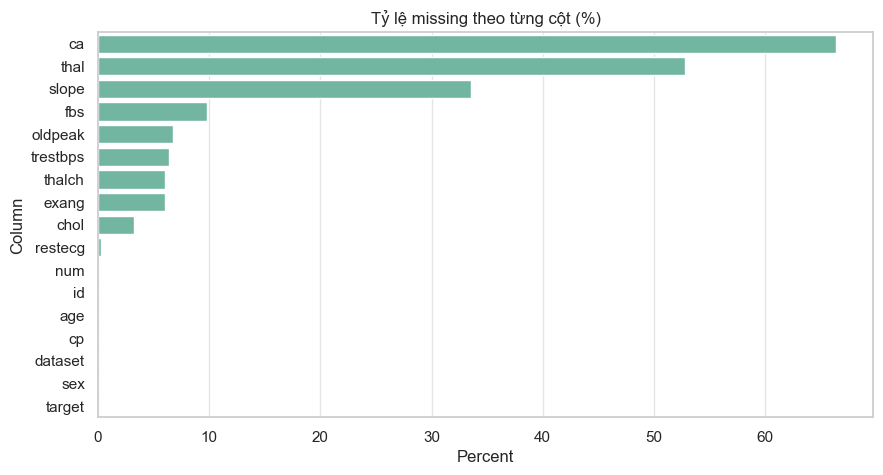

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(x='missing_percent', y='column', data=missing_summary)
plt.title('Tỷ lệ missing theo từng cột (%)')
plt.xlabel('Percent')
plt.ylabel('Column')
plt.show()

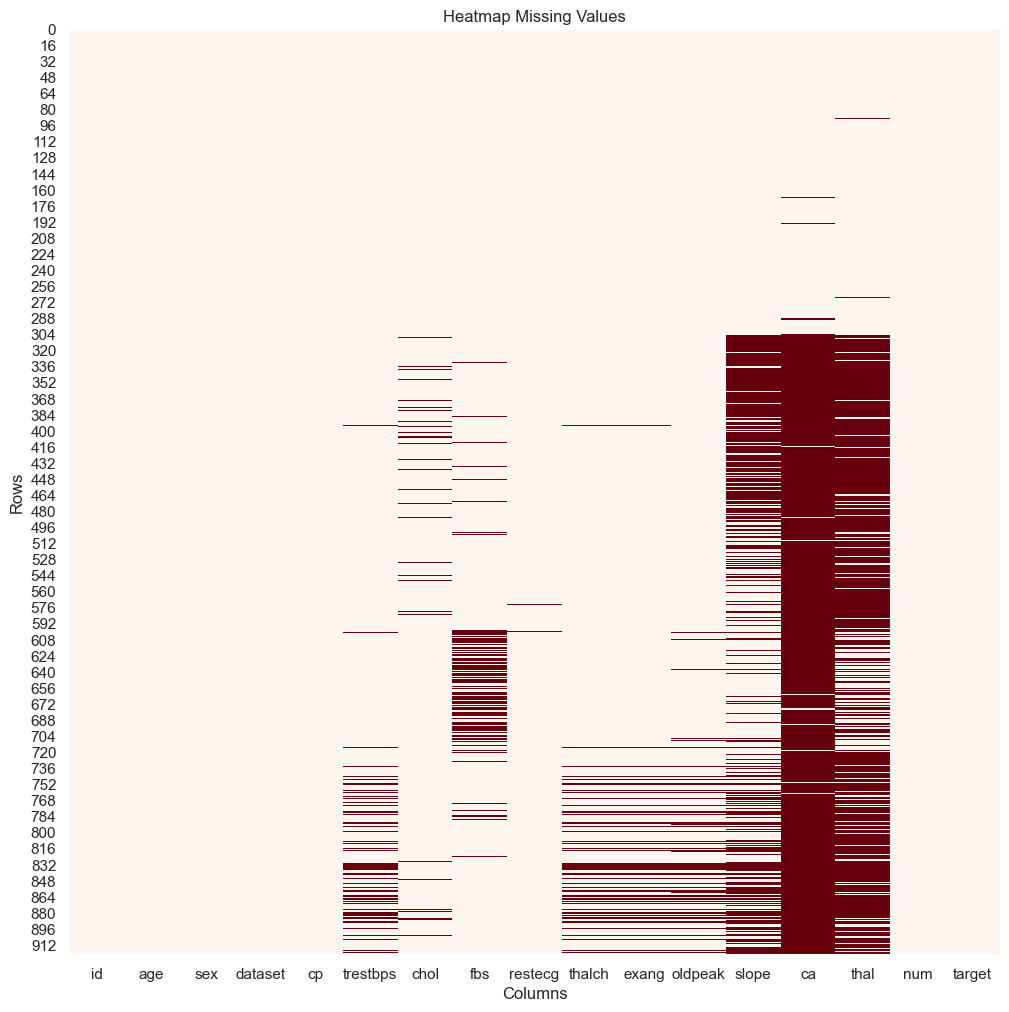

In [15]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title('Heatmap Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

**Các cột có tỉ lệ missing value > 50%**

In [16]:
# tổng số missing toàn dataset
total_missing = df.isnull().sum().sum()
print("Tổng số giá trị thiếu:", total_missing)

# cột nào > 50% missing
high_missing_cols = missing_summary[missing_summary['missing_percent'] > 50]
print("Cột có >50% missing:\n", high_missing_cols.round(2))

Tổng số giá trị thiếu: 1759
Cột có >50% missing:
      column  missing_count  missing_percent
ca       ca            611            66.41
thal   thal            486            52.83


**Nhận xét :**
- Dataset có tình trạng thiếu dữ liệu khá rõ rệt, đặc biệt ở một số cột quan trọng.
- Hai cột ca và thal có tỷ lệ thiếu vượt quá 50%, điều này ảnh hưởng trực tiếp đến chất lượng mô hình nếu không xử lý.
- Một số cột khác như slope (33.6%), fbs (9.8%), oldpeak (6.7%), trestbps (6.4%) cũng có tỷ lệ thiếu đáng kể, cần cân nhắc phương pháp điền giá trị hoặc loại bỏ.
- Các cột còn lại nhìn chung khá đầy đủ, tỷ lệ thiếu thấp (<10%), có thể xử lý đơn giản.
- Không thấy pattern thiếu dữ liệu theo hàng, nghĩa là dữ liệu bị thiếu mang tính ngẫu nhiên.

### 4. Target Analysis

**Phân tích biến mục tiêu (Target Analysis)** nhằm hiểu rõ phân phối, mức độ cân bằng và chất lượng của biến dự đoán trước khi xây dựng mô hình. Trong nghiên cứu này, nhóm sử dụng biểu đồ CountPlot để phân tích cột `target` từ dataset.

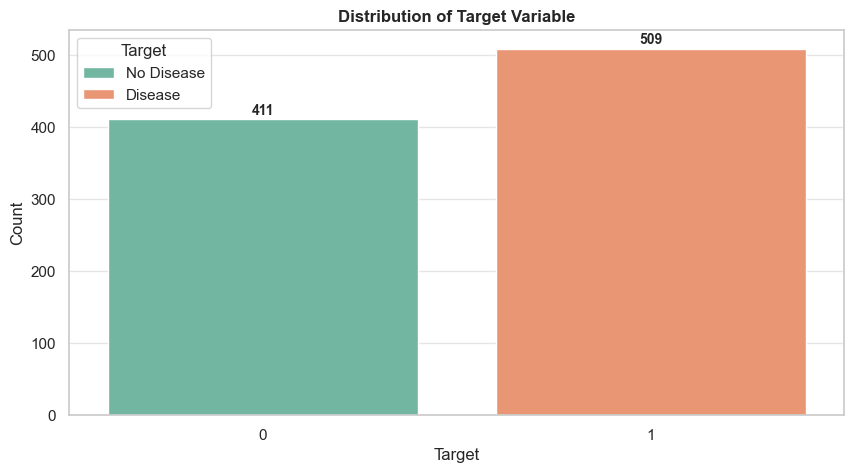

In [17]:
# Vẽ biểu đồ cột cho thấy số lượng giá trị bệnh và không bệnh trong target
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x='target', hue='target')

# Gán nhãn cho các cột
for c in ax.containers:
    ax.bar_label(container=c, fontsize=10, fontweight='bold', padding=1)

# Đổi legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Disease', 'Disease'], title="Target")

# Tiêu đề
ax.set_title("Distribution of Target Variable", fontweight='bold')
ax.set_xlabel("Target")
ax.set_ylabel("Count")

plt.show()

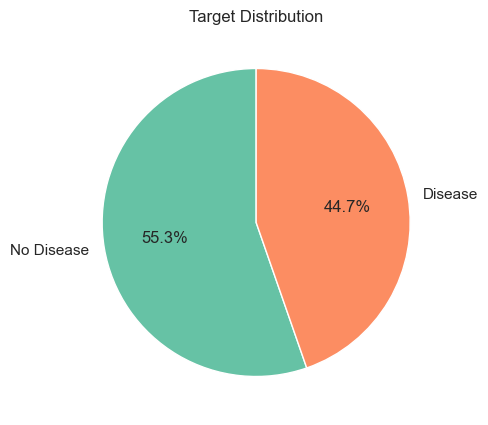

In [18]:
# Tính tỉ lệ phân phối biến mục tiêu
disease_percent = df['target'].value_counts(normalize=True)

# Vẽ biểu đồ tròn thể hiện tỉ lệ phân phối biến mục tiêu
plt.figure(figsize=(5, 5))
plt.pie(disease_percent,
        labels=['No Disease', 'Disease'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Target Distribution")

plt.show()

 **Nhận xét:**

- **Số lượng:** Tập dữ liệu gồm **411** trường hợp không mắc bệnh và **509** trường hợp mắc bệnh.

- **Tỷ lệ phân phối:** Nhóm không mắc bệnh chiếm khoảng **44.7%**, trong khi nhóm mắc bệnh chiếm khoảng **55.3%**, cho thấy sự chênh lệch không đáng kể giữa hai lớp.

- **Ý nghĩa mô hình:** Với phân phối tương đối cân bằng này, mô hình có thể học ổn định trên cả hai lớp mà không cần áp dụng các kỹ thuật xử lý mất cân bằng phức tạp.

### 5. Categorical Analysis

**Phân tích biến phân loại(Categorical Analysis)** nhằm hiểu rõ phân phối và tần suất xuất hiện của các nhóm dữ liệu định tính trong tập dữ liệu, từ đó hỗ trợ đánh giá đặc điểm dữ liệu và mối quan hệ với biến mục tiêu.

Trong nghiên cứu này, nhóm sử dụng biểu đồ **CountPlot** để trực quan hóa các biến phân loại như giới tính, loại đau ngực, kết quả điện tâm đồ,... Qua đó, có thể quan sát được sự phân bố của từng nhóm và phát hiện các đặc điểm nổi bật hoặc sự chênh lệch giữa các giá trị.

Việc phân tích này giúp cung cấp cái nhìn tổng quan về dữ liệu, đồng thời hỗ trợ quá trình lựa chọn đặc trưng và xây dựng mô hình hiệu quả hơn.

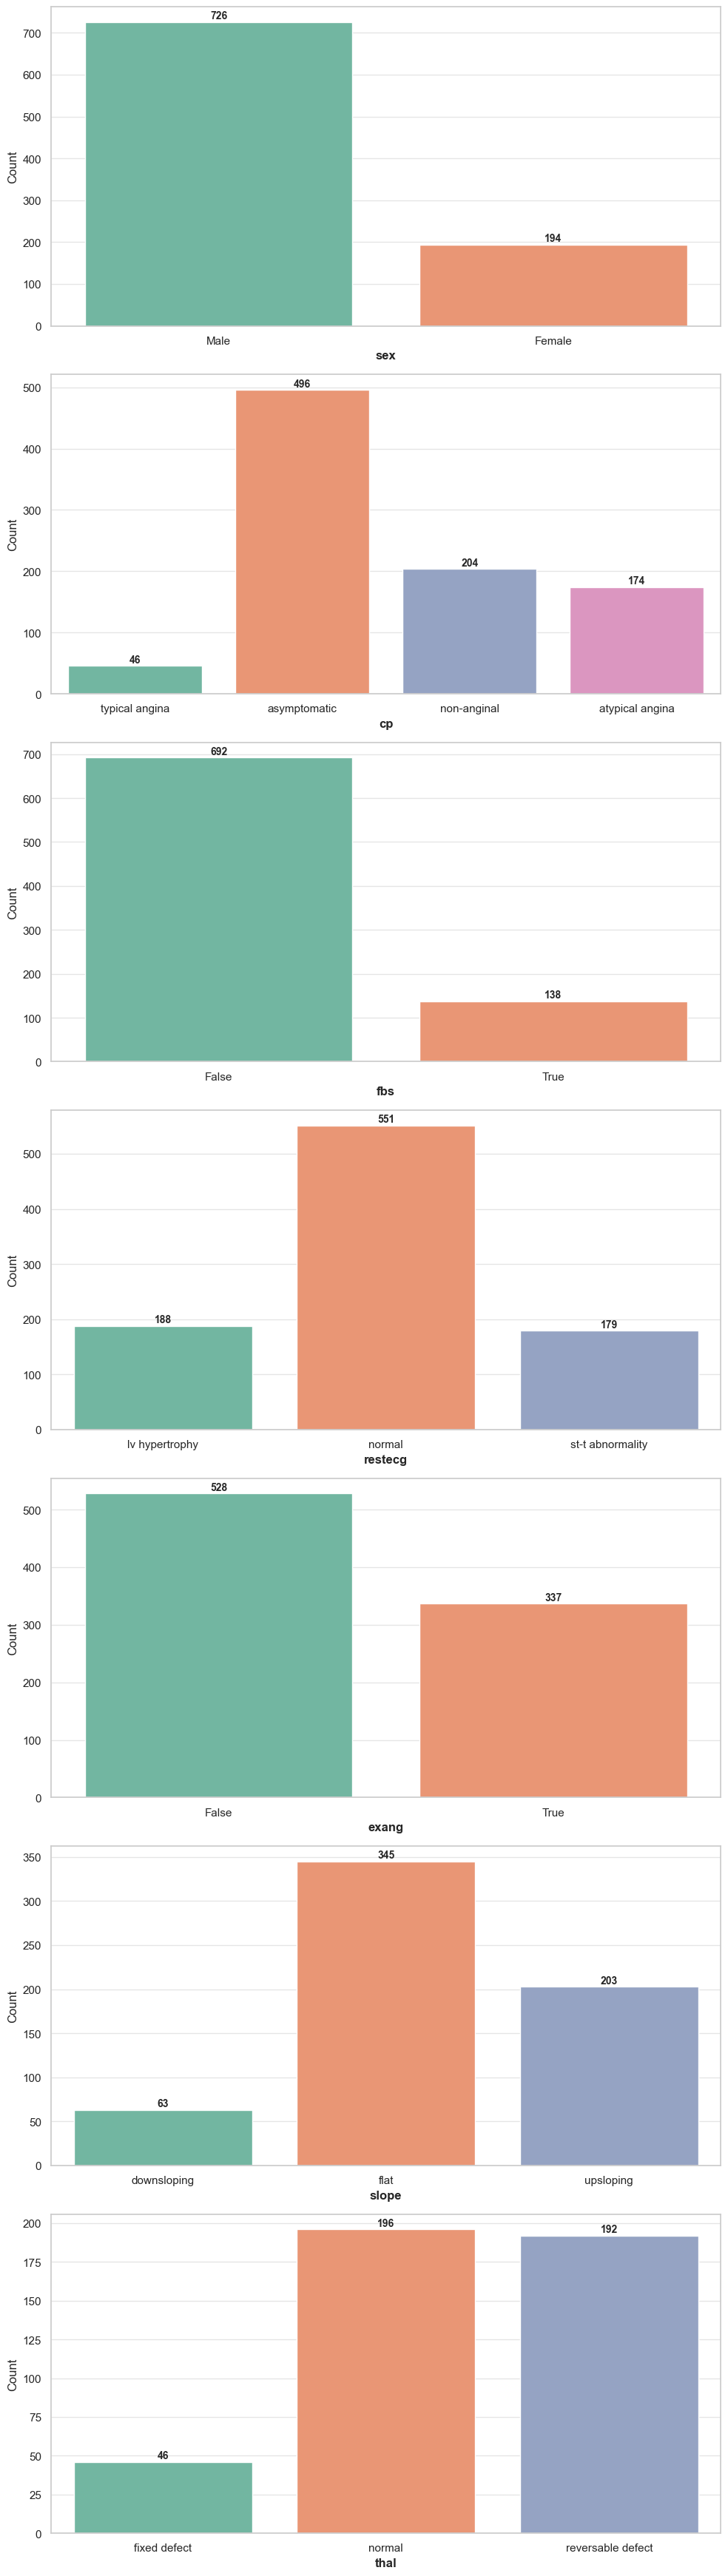

In [19]:
# Vẽ các biểu đồ countplot cho danh sách các biến phân loại
fig, axes = plt.subplots(nrows=len(cat_cols), figsize=(10, 5 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(data=df, x=col, hue=col, ax=ax, legend=False)

    for c in ax.containers:
        ax.bar_label(container=c, fontsize=10, fontweight='bold', padding=1)

    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Nhận xét:**

**-Tại biểu đồ sex:** Dữ liệu có sự mất cân bằng giới tính. Số lượng Nam giới tham gia khảo sát đông hơn rất nhiều so với Nữ giới (726 Nam so với 194 Nữ).

**-Tại biểu đồ cp:** Đau ngực loại asymptomatic (không triệu chứng) chiếm tỷ lệ cao nhất (496 ca). Các loại đau thắt ngực điển hình (typical angina) chiếm tỷ lệ thấp nhất (46 ca).

**-Tại biểu đồ fbs:** Đa số người tham gia có đường huyết lúc đói dưới 120 mg/dl (692 ca). Chỉ có một nhóm nhỏ (138 ca) có chỉ số đường huyết cao (> 120 mg/dl).

**-Tại biểu đồ exang:** Số lượng người không bị đau ngực khi vận động (False - 528 ca) cao hơn đáng kể so với nhóm có bị đau ngực khi vận động (True - 337 ca).

**-Tại biểu đồ restecg:** Kết quả điện tâm đồ lúc nghỉ ngơi phần lớn là normal (551 ca). Các tình trạng bất thường như lv hypertrophy hay st-t abnormality chiếm số lượng ít hơn và khá tương đồng nhau.

**-Tại biểu đồ slope:** Độ dốc của đoạn ST sau tập luyện chủ yếu là flat (345 ca) và upsloping (203 ca). Loại downsloping chiếm tỷ lệ rất thấp (63 ca).

**-Tại biểu đồ thal:** Tình trạng thiếu máu cục bộ cơ tim phổ biến nhất là normal (196 ca) và reversable (192 ca). Loại fixed defect chỉ chiếm một phần nhỏ (46 ca).

**Kết luận:** Tập dữ liệu cho thấy đối tượng khảo sát điển hình là Nam giới, có kết quả điện tâm đồ bình thường, nhưng phần lớn lại gặp tình trạng đau ngực không triệu chứng (asymptomatic). Đây là một điểm đáng lưu ý vì bệnh có thể tiến triển âm thầm mà không có biểu hiện đau thắt ngực điển hình.

### 6. Distribution Analysis

**Phân tích phân phối (Distribution Analysis)** là quan sát các giá trị trong một cột dữ liệu được phân bố như thế nào và dữ liệu được tập trung ở đâu hay dữ liệu có bị lệch hay không?
Phân tích phân phối giúp ta xác định:
* Dữ liệu có bị lệch hay không?
* Feature nào quan trọng với mô hình?
* Feature nào không quan trọng?

Ở đây, nhóm chọn biểu đồ **KDE ()** vì biểu đồ này thể hiện sự chồng lên nhau của 2 nhóm có bệnh và không bệnh rõ ràng nhất.

Trong phần này, nhóm sẽ tập chung phân tích các cột dữ liệu là: age, trestbps, chol, thalch, oldpeak, ca vì các cột này có dữ liệu là numerical liên tục trong 1 khoảng.

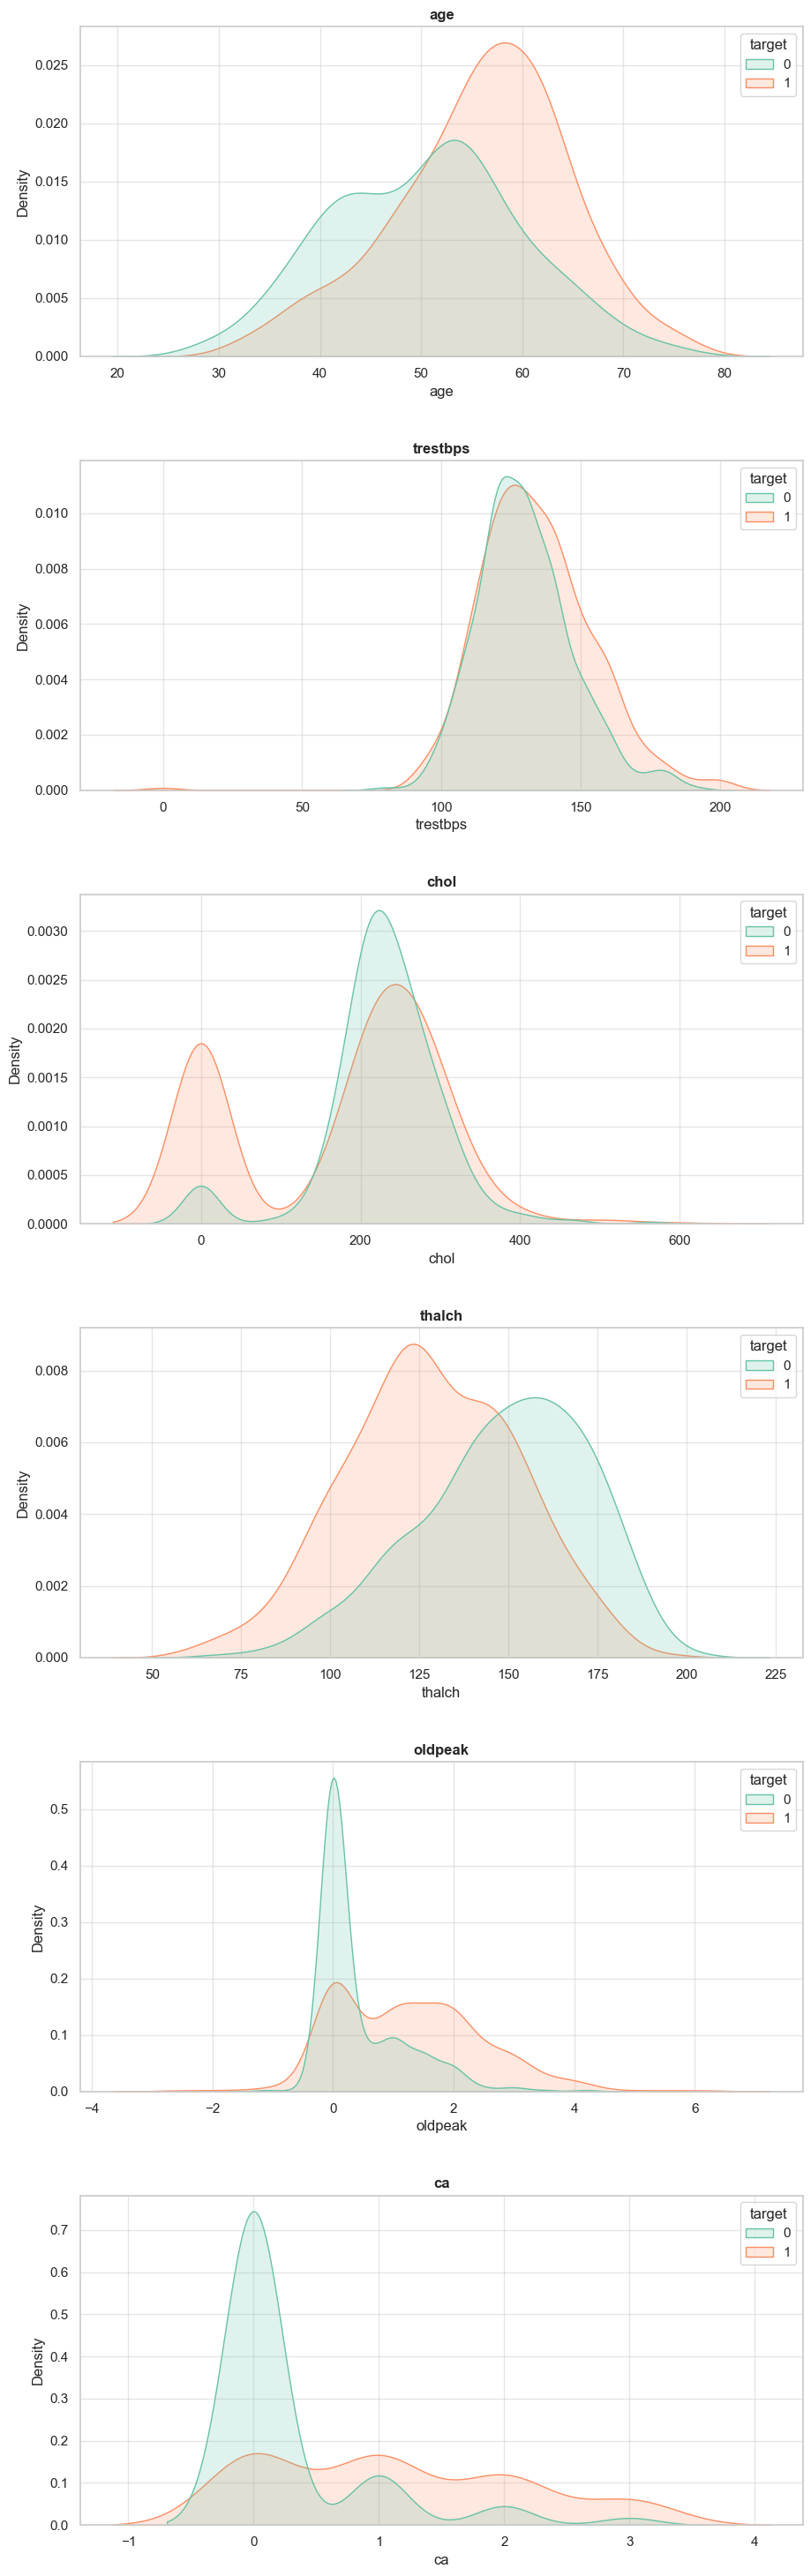

In [20]:
# Vẽ biểu đồ KDE
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
        sns.kdeplot(
            data=df,
            x=col,
            hue='target',
            ax=axes[i],
            fill=True,
            alpha=0.2
        )
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel(col)
plt.tight_layout(pad=3.0)
plt.show()

**Nhận xét:**
* **age**:
    * Nhóm không bệnh phân bố tập trung ở độ tuổi 40 - 55
    * Nhóm có bệnh phân bố tập trung ở độ tuổi 55 - 60

    Hai nhóm có chồng lên nhau nhưng dữ liệu có phần lệch hơn về phía bên phải

    -> Feature này có giá trị trung bình
* **trestbps**:

    Hai nhóm phân phối lệch phải và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **chol**:

    Hai nhóm phân phối lệch trái và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **thalch**:

    Nhóm không bệnh phân bố tập trung ở mức nhịp tim cao, từ 150 - 165

    Nhóm có bệnh phân bố tập trung ở mức nhịp tim thấp hơn, từ 120 - 135

    Hai nhóm tách biệt nhau khá rõ ràng và ít bị chồng chéo, điểm giao cắt rõ nét ở khoảng 145 - 150.

    -> Feature này có giá trị phân loại cao (mạnh nhất).
* **oldpeak**:

    Nhóm không bệnh phân bố tập trung rất cao tại mốc 0.

    Nhóm có bệnh phân bố trải dài hơn, tạo thành các khoảng tập trung ở gần mốc 0 và từ 1.0 đến 2.5.

    Hai nhóm có chồng lên nhau ở mốc 0 nhưng hình dáng khác biệt rõ rệt. Dữ liệu của nhóm có bệnh có phần đuôi dài, lệch hẳn về phía bên phải (lên tới mức 4.0 trở lên).

    -> Feature này có giá trị cao.
* **ca**:

    Nhóm không bệnh phân bố tập trung rất cao tại giá trị **0**, cho thấy đa số bệnh nhân không mắc bệnh không có mạch vành bị nhuộm màu.

    Ngược lại, nhóm có bệnh phân bố trải rộng hơn từ **0 đến 3**, với mật độ giảm dần khi giá trị tăng. Đặc biệt, nhóm này có tần suất xuất hiện đáng kể ở các giá trị **1, 2 và 3**, trong khi nhóm không bệnh gần như không xuất hiện ở các mức này.

    Hai nhóm có sự chồng lấn tại giá trị 0, tuy nhiên từ giá trị **>= 1** trở đi, sự tách biệt trở nên rõ ràng hơn.

    -> Feature này có giá trị phân loại cao.

**=> Tóm lại**, các đặc trưng **thalch, oldpeak và ca** mang lại giá trị phân loại cao.


### 7. Outlier Analysis

**Phân tích giá trị ngoại lệ (Outlier Analysis)** nhằm phát hiện các giá trị bất thường (outliers) trong tập dữ liệu. Các giá trị này có thể là dữ liệu thực (ví dụ: bệnh nhân có chỉ số rất cao) hoặc do lỗi nhập liệu / dữ liệu thiếu.

Trong nghiên cứu này, các biến y tế như **age, trestbps, chol, thalch, oldpeak** có khả năng xuất hiện các giá trị cực đoan. Nếu không được phát hiện và xử lý kịp thời, các giá trị này có thể làm sai lệch kết quả phân tích thống kê và ảnh hưởng tiêu cực đến hiệu suất của mô hình machine learning.

Do đó, việc thực hiện Outlier Analysis là cần thiết để đảm bảo chất lượng dữ liệu trước khi tiến hành các bước phân tích và xây dựng mô hình tiếp theo.

In [21]:
# Hàm vẽ Boxplot :  Boxplot giúp trực quan hóa phân bố dữ liệu và dễ dàng nhận ra các điểm nằm ngoài phạm vi bình thường.
def plot_boxplot(df, column):
    """
    Vẽ boxplot cho một cột số trong DataFrame.

    Args:
        df (pd.DataFrame): DataFrame chứa dữ liệu đầu vào.
        column (str): Tên cột cần vẽ boxplot.
    """
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [22]:
# Phát hiện Outlier bằng phương pháp IQR : Phương pháp **Interquartile Range (IQR)** được sử dụng để xác định các giá trị bất thường.
def detect_outlier(df, column):
    """
    Phát hiện outlier trong một cột số bằng phương pháp IQR.

    Args:
        df (pd.DataFrame): DataFrame chứa dữ liệu đầu vào.
        column (str): Tên cột cần kiểm tra outlier.

    Returns:
        pd.DataFrame: Các hàng chứa giá trị nằm ngoài khoảng
            [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\n===== Outlier in {column} =====")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))

    return outliers

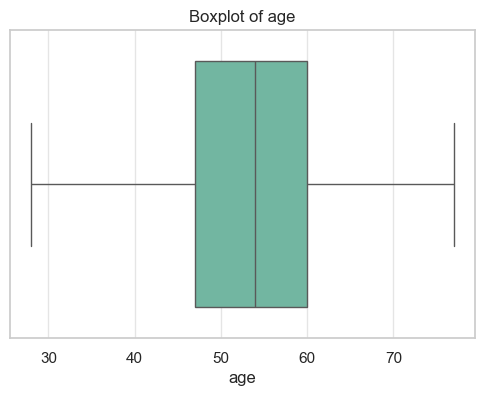


===== Outlier in age =====
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0


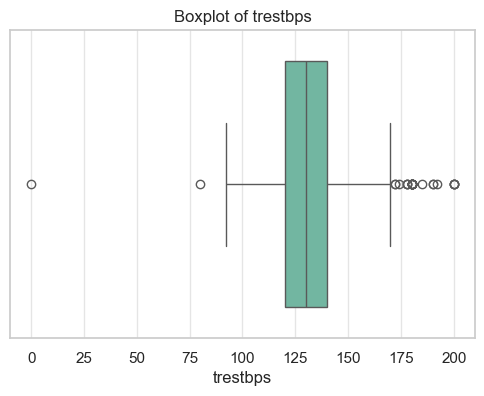


===== Outlier in trestbps =====
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 28


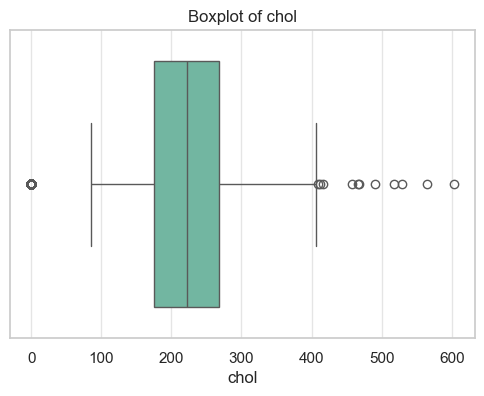


===== Outlier in chol =====
Lower bound: 35.5
Upper bound: 407.5
Number of outliers: 183


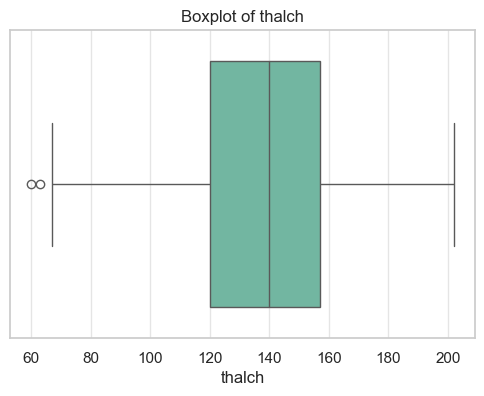


===== Outlier in thalch =====
Lower bound: 64.5
Upper bound: 212.5
Number of outliers: 2


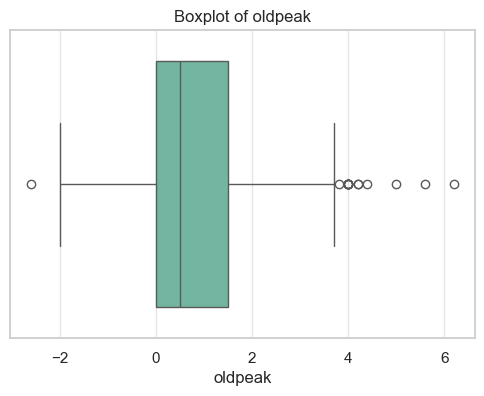


===== Outlier in oldpeak =====
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16


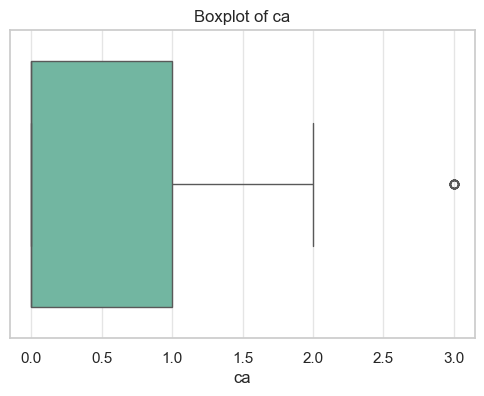


===== Outlier in ca =====
Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 20


In [23]:
# Phân tích Outlier cho từng biến:  Vẽ boxplot và Tính số lượng outlier bằng IQR
for col in num_cols:
    plot_boxplot(df, col)
    detect_outlier(df, col)

In [24]:
# Kiểm tra giá trị cực trị (Min và Max): Sau khi phát hiện outlier, chúng ta cần kiểm tra **giá trị nhỏ nhất và lớn nhất** để xác định: Outlier là dữ liệu thật hay lỗi nhập liệu
for col in num_cols:
    print(f"\nColumn: {col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Column: age
Min: 28
Max: 77

Column: trestbps
Min: 0.0
Max: 200.0

Column: chol
Min: 0.0
Max: 603.0

Column: thalch
Min: 60.0
Max: 202.0

Column: oldpeak
Min: -2.6
Max: 6.2

Column: ca
Min: 0.0
Max: 3.0


Nhận xét Outlier:
Kết quả cho thấy:
Cholesterol có nhiều outlier hơn các biến khác.
Một số giá trị như chol = 0 hoặc trestbps = 0 không hợp lý về mặt y học.

Ví dụ:
- Cholesterol không thể bằng 0
- Huyết áp không thể bằng 0

Do đó các giá trị này có thể là lỗi nhập liệu hoặc missing values.

### 8. Correlation Analysis

**Phân tích tương quan (Correlation Analysis)** là phương pháp thống kê đánh giá mức độ liên quan giữa 2 hoặc nhiều biến số.

Phân tích tương quan giúp ta xác định:

- Feature nào liên quan mạnh nhất đến bệnh tim?
- Có 2 feature nào mang thông tin trùng lặp nhau không?
- Feature nào nên ưu tiên khi xây dựng mô hình?

Ở đây, nhóm chọn biểu đồ **Heatmap** vì biểu đồ này thể hiện
toàn bộ mối quan hệ giữa tất cả các feature cùng lúc thông qua
màu sắc — màu càng đậm thì tương quan càng mạnh.

Hệ số tương quan có giá trị từ -1 đến 1, trong đó 1 là
tương quan thuận hoàn toàn, 0 là không có tương quan, và -1
là tương quan nghịch hoàn toàn.

Trong phần này, nhóm sẽ encode các cột categorical sang dạng số
trước khi tính tương quan vì hệ số Pearson chỉ tính được trên dữ
liệu số. Việc encode chỉ dùng trong section này, không thay đổi
dữ liệu gốc.

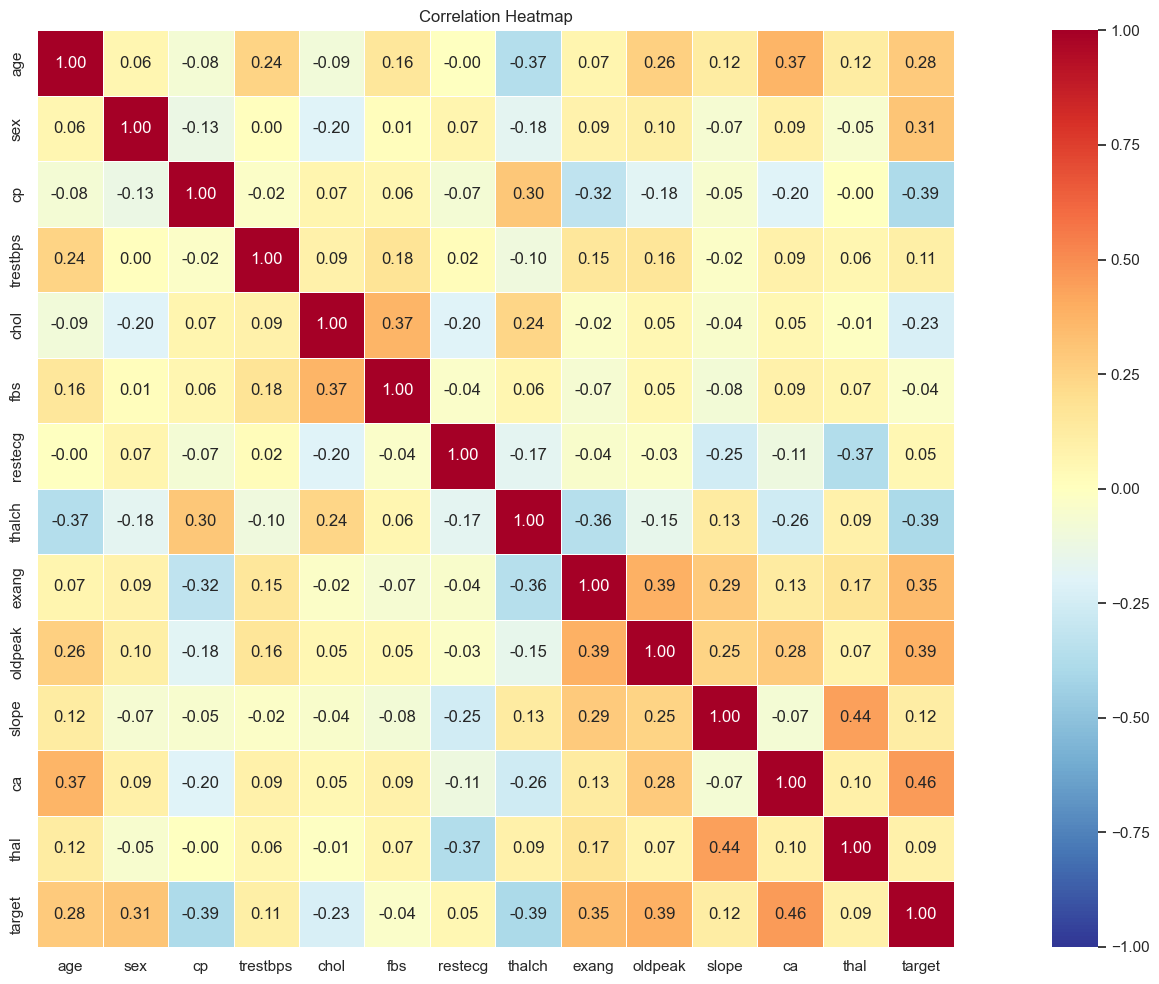

tương quan các cột với target theo độ mạnh:
ca          0.46
thalch     -0.39
oldpeak     0.39
cp         -0.39
exang       0.35
sex         0.31
age         0.28
chol       -0.23
slope       0.12
trestbps    0.11
thal        0.09
restecg     0.05
fbs        -0.04
Name: target, dtype: float64


In [25]:
# Encode các categorical feature
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

#trong biểu đồ heatmap này các cột id, dataset không có ý nghĩa so sánh và cột num đã được chuyển thành target, nên không cần dùng các cột này
df_encoded = df_encoded.drop(columns=['id', 'dataset', 'num'])

# Tính ma trận tương quan
corr_matrix = df_encoded.corr()

plt.figure(figsize=(20, 10))
sns .heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cmap='RdYlBu_r'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('tương quan các cột với target theo độ mạnh:')
print(corr_matrix['target'].drop('target').sort_values(key=abs,ascending=False).round(2))

**Nhận xét:**
* Các feature tương quan mạnh với target (|r| > 0.3):

| Feature | Hệ số | Ý nghĩa |
|---|---|---|
| ca | +0.46 | Số mạch vành bị tắc càng nhiều -> nguy cơ bệnh càng cao |
| thalch | -0.39 | Nhịp tim tối đa càng thấp -> nguy cơ bệnh càng cao |
| oldpeak | +0.39 | ST depression càng cao -> nguy cơ bệnh càng cao |
| cp | -0.39 | Loại đau ngực có liên quan rõ đến bệnh tim |
| exang | +0.35 | Đau ngực khi gắng sức -> dấu hiệu rõ của bệnh tim |
| sex | +0.31 | Giới tính có ảnh hưởng đến nguy cơ bệnh tim |

* Những feature còn lại có tương quan yếu hoặc gần như không tương quan với target

* Những feature có tương quan mạnh với nhau:

| Cặp Feature | Hệ số | Ý nghĩa |
|---|---|---|
| slope vs thal | +0.44 | Khá trùng lặp |
| exang vs oldpeak | +0.39 | Có liên quan nhau |
| chol vs fbs | +0.37 | Cholesterol cao đi đôi với đường huyết cao |
| ca vs age | +0.37 | Người lớn tuổi -> mạch vành dễ bị tắc hơn |
| thalch vs age | -0.37 | Người lớn tuổi -> nhịp tim tối đa thấp hơn |
| thal vs restecg | -0.37 | Kết quả thalassemia liên quan đến ECG |
| thalch vs exang | -0.36 | Nhịp tim tối đa thấp đi đôi với đau ngực khi gắng sức |
| exang vs cp | -0.32 | Loại đau ngực liên quan đến đau khi gắng sức |

**=> Tóm lại,**

- Các feature tương quan mạnh với target có: ca, thalch, oldpeak, cp, exang và sex
-> ưu tiên giữ lại các feature này.

- Các feature tương quan yếu có: thal, restecg và fbs

- Các cặp feature có tương quan mạnh có: slope và thal, exang và oldpeak

### 9. Preprocessing Strategy

Dựa trên các phân tích EDA, nhóm thiết lập chiến lược tiền xử lý như sau:

**1. Xử lý dữ liệu lỗi (Data Errors)**
* Chuyển các giá trị `0` ở cột `trestbps` (huyết áp) và `chol` (cholesterol) thành `NaN`. Theo kết quả thống kê mô tả (describe), giá trị min = 0 ở các cột này là vô lý về mặt y khoa (lỗi nhập liệu). Cần đưa về dạng Missing Value để Pipeline xử lý đồng nhất.

**2. Feature Selection (Các cột cần Drop)**
Nhóm tiến hành loại bỏ các cột không mang giá trị dự đoán hoặc gây rò rỉ dữ liệu (Data Leakage):
* `id`, `dataset`: Là định danh và nguồn dữ liệu, nếu giữ lại mô hình sẽ học vẹt theo nguồn bệnh viện thay vì triệu chứng lâm sàng.
* `num`: Cột gốc của biến mục tiêu (0-4). Đã được xử lý thành cột `target` nhị phân (0: không bệnh, 1: có bệnh) nên sẽ bị loại bỏ trước khi train.
* `ca` (số mạch máu chính): Drop. Cột này bị khuyết tới 66.41%. Quan trọng hơn, thông số `ca` thường có được sau khi can thiệp xét nghiệm sâu (chụp mạch). Đối với một Web App dự đoán rủi ro bệnh tim sớm, việc giữ lại `ca` gần như là "biết trước đáp án", làm giảm ý nghĩa thực tế của mô hình.
* `thal` (tình trạng máu): Drop. Tương tự `ca`, cột này khuyết tới 52.83% và mang tính chất xét nghiệm chuyên sâu, ít tương quan mạnh với các triệu chứng khám lâm sàng ban đầu.

**3. Chiến lược Điền khuyết (Imputation)**
* **Biến số (Numerical):** Sử dụng `Median` (Trung vị). Biểu đồ phân phối ở phần EDA cho thấy các biến như `chol` hay `oldpeak` có độ lệch (skew) và chứa các giá trị ngoại lai (outliers). Dùng Mean sẽ bị kéo lệch, do đó Median là phương án an toàn nhất.
* **Biến phân loại (Categorical):** Sử dụng `Mode` (Giá trị xuất hiện nhiều nhất) để duy trì cấu trúc phân phối tập dữ liệu.

**4. Chuẩn hóa & Mã hóa (Scaling & Encoding)**
* **Numerical:** Dùng `StandardScaler`. EDA cho thấy dải giá trị các cột chênh lệch cực kỳ lớn (ví dụ `chol` từ hàng trăm, trong khi `oldpeak` chỉ từ 0-6). Nếu không chuẩn hóa, các mô hình nhạy cảm với khoảng cách (LR, SVM) sẽ hội tụ kém hoặc học sai.
* **Categorical:** Dùng `OneHotEncoder(handle_unknown='ignore')` để tránh lỗi hệ thống khi tập test hoặc dữ liệu thực tế xuất hiện nhãn chưa từng gặp ở tập train.

**5. Feature Engineering (Kỹ thuật Đặc trưng)**
* Nhóm dự kiến sẽ nghiên cứu và bổ sung thêm một số đặc trưng tổng hợp mới (dựa trên sự kết hợp của các chỉ số sinh tồn) ở bước sau, nhằm giúp mô hình bắt được các yếu tố rủi ro phức tạp hơn trước khi đưa vào Pipeline.

## III. PREPROCESSING

### 1. Outlier & Data Error Handling

Trong bước này, chúng ta sẽ xử lý các giá trị vô lý về mặt lâm sàng (ngoại lai/lỗi) được phát hiện trong quá trình Phân tích Dữ liệu Khám phá (EDA). Cụ thể, hai biến `trestbps` (huyết áp) và `chol` (cholesterol) có giá trị nhỏ nhất bằng `0`, điều này là hoàn toàn không thể xảy ra về mặt sinh học.

Thay vì xóa bỏ các dòng dữ liệu này (việc xóa dòng sẽ gây ra lỗi không khớp kích thước chiều dữ liệu giữa `X` và `y` khi chạy bên trong Pipeline của scikit-learn), chúng ta sẽ chuyển đổi các giá trị `0` này thành `NaN`. Các giá trị khuyết (missing values) này sau đó sẽ được xử lý một cách an toàn bởi bộ điền khuyết (Imputer) ở các bước tiếp theo trong pipeline.

In [26]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    """Xử lý các giá trị bất hợp lệ về mặt lâm sàng bằng cách thay thế bằng NaN."""
    def fit(self, X, y=None):
        """
        Không học tham số, trả về self để tương thích với Pipeline.

        Args:
            X (pd.DataFrame): Dữ liệu đầu vào.
            y: Bỏ qua, chỉ có mặt để tương thích với scikit-learn API.

        Returns:
            self: Trả về chính transformer.
        """
        # Return self vì bước này không cần học tham số (như mean/std) từ tập train
        return self

    def transform(self, X):
        """Thay thế các giá trị 0 bất khả thi lâm sàng bằng NaN.

        Các cột 'trestbps' (huyết áp) và 'chol' (cholesterol) không thể
        có giá trị 0 trên thực tế, nên 0 được coi là dữ liệu bị thiếu.

        Args:
            X (pd.DataFrame): DataFrame chứa ít nhất hai cột
                'trestbps' và 'chol'.

        Returns:
            pd.DataFrame: Bản sao của X với các giá trị 0 trong
                'trestbps' và 'chol' đã được thay thế bằng NaN.
        """
        X_new = X.copy()

        # 0 là giá trị bất khả thi trên lâm sàng đối với huyết áp và cholesterol
        X_new['trestbps'] = X_new['trestbps'].replace(0, np.nan)
        X_new['chol'] = X_new['chol'].replace(0, np.nan)

        return X_new

### 2. Feature Engineering

Giải thích lí do tạo ra các feature này:

**Feature 1: heart_rate_ratio — Tỷ lệ nhịp tim đạt được**

Công thức Karvonen trong y học: nhịp tim tối đa lý thuyết của một người = 220 trừ tuổi. Đây là ngưỡng tối đa tim có thể đập được. Khi bác sĩ làm stress test (kiểm tra gắng sức), họ theo dõi bệnh nhân có đạt được bao nhiêu % ngưỡng tối đa này. Ý nghĩa lâm sàng: người đạt < 85% ngưỡng tối đa trong stress test có nguy cơ bệnh tim mạch cao hơn đáng kể. Bác sĩ gọi đây là 'chronotropic incompetence'. Feature heart_rate_ratio chính là cách đo tỷ lệ này.

**Cách tính:** Lấy giá trị thalach chia cho (220 trừ age). Kết quả là số thực từ 0 đến ~1.1.

**Tại sao tốt hơn dùng riêng thalach?**
 Bởi vì thalach=150 có ý nghĩa khác nhau hoàn toàn tùy theo tuổi. Người 30 tuổi có thalach=150 đang đạt 75% khả năng tối đa (150/200). Người 70 tuổi có thalach=150 đang đạt 100% (150/150) — xuất sắc. Feature mới nắm bắt được sự phụ thuộc phi tuyến này.

**Feature 2: age_risk_group — Nhóm nguy cơ theo tuổi**

Nguy cơ bệnh tim mạch không tăng tuyến tính (đều đặn) theo tuổi. Nghiên cứu lâm sàng cho thấy nguy cơ tăng vọt tại các ngưỡng nhất định: sau 40 tuổi, sau 50 tuổi, và sau 60 tuổi. Đây là hiện tượng 'threshold effect' — ngưỡng nguy hiểm. Nếu dùng age trực tiếp, model tuyến tính (như Logistic Regression) khó nhận ra được các ngưỡng phi tuyến này. Nhóm hóa giúp 'biến đổi' mối quan hệ phi tuyến thành dạng mà model có thể học được

**Cách tính:** Phân nhóm age thành 4 nhóm: 0–40 (nhóm 0), 40–50 (nhóm 1), 50–60 (nhóm 2), 60+ (nhóm 3). Kết quả là số nguyên 0–3 thể hiện mức nguy cơ tăng dần.



In [27]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Tạo các đặc trưng mới (Feature Engineering) dựa trên kiến thức y khoa lâm sàng."""

    def fit(self, X, y=None):
        """
        Không học tham số, trả về self để tương thích với Pipeline.

        Args:
            X (pd.DataFrame): Dữ liệu đầu vào.
            y: Bỏ qua, chỉ có mặt để tương thích với scikit-learn API.

        Returns:
            self: Trả về chính transformer.
        """
        return self

    def transform(self, X):
        """Tạo hai đặc trưng mới: tỷ lệ nhịp tim (heart_rate_ratio) và nhóm rủi ro theo tuổi (age_risk_group).

        - 'heart_rate_ratio': Tỷ lệ giữa nhịp tim thực tế ('thalch') và ngưỡng tối đa lý thuyết (220 - 'age').
        - 'age_risk_group': Phân nhóm độ tuổi thành 4 mức rủi ro (0: 0-40, 1: 40-50, 2: 50-60, 3: 60+)
          dựa trên hiệu ứng ngưỡng nguy hiểm.

        Args:
            X (pd.DataFrame): DataFrame chứa ít nhất hai cột
                'age' và 'thalch'.

        Returns:
            pd.DataFrame: Bản sao của X đã được bổ sung thêm hai cột
                mới là 'heart_rate_ratio' và 'age_risk_group'.
        """
        X_new = X.copy()

        # 1. Feature: heart_rate_ratio
        X_new['heart_rate_ratio'] = X_new['thalch'] / (220 - X_new['age'])

        # 2. Feature: age_risk_group
        # Chia bins: 0–40 (0), 40–50 (1), 50–60 (2), 60+ (3)
        bins = [0, 40, 50, 60, np.inf]
        labels = [0, 1, 2, 3]
        X_new['age_risk_group'] = pd.cut(X_new['age'], bins=bins, labels=labels).astype(int)

        return X_new

### 3. Drop Columns & Train-Test Split

Trước khi tiến hành các bước chuẩn hóa số liệu, chúng ta bắt buộc phải chia tập dữ liệu (Train/Test) để tuân thủ tuyệt đối nguyên tắc chống rò rỉ dữ liệu (Data Leakage).

Các công việc trong bước này:
1. **Loại bỏ cột rác:** Xóa bỏ `id`, `dataset`, `num` (nếu còn), `ca`, và `thal` theo đúng chiến lược đã quyết ddịnh.
2. **Phân chia dữ liệu:** Dùng `test_size=0.2` và bắt buộc dùng `stratify=y` (với `y` là cột `target` đã tạo từ phần EDA) để duy trì tỷ lệ lớp giữa tập train và test.

In [28]:
#Các cột cần drop theo quyết định ở phần trước
drop_cols = ['id', 'dataset', 'num', 'ca', 'thal', 'target']
X = df.drop(columns=drop_cols)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (736, 11)
y_train shape: (736,)
X_test shape: (184, 11)
y_test shape: (184,)


Kiểm tra kết quả:
1. Kích thước đúng: X_train ~80%, X_test ~20%
2. Tỷ lệ bệnh và không bệnh giống nhau ở 2 tập

In [29]:
print("Kích thước tập Train:", y_train.shape[0]/y.shape[0] * 100, "%")
print("Kích thước tập Test:", y_test.shape[0]/y.shape[0] * 100, "%")
print()

print("Tỷ lệ class trong y_train:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Tỷ lệ class trong y_test:")
print(y_test.value_counts(normalize=True).round(3))

Kích thước tập Train: 80.0 %
Kích thước tập Test: 20.0 %

Tỷ lệ class trong y_train:
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Tỷ lệ class trong y_test:
target
1    0.554
0    0.446
Name: proportion, dtype: float64


### 4. Build Full Preprocessor Pipeline

**Pipeline là gì?**
Pipeline là công cụ của sklearn cho phép nối nhiều bước xử lý
thành một chuỗi tự động. Khi gọi fit(), Pipeline lần lượt gọi
fit() của từng bước theo đúng thứ tự. Khi gọi transform(),
Pipeline áp dụng transform() của từng bước lên dữ liệu.

**Tại sao dùng Pipeline thay vì xử lý thủ công từng bước?**
- Đảm bảo thứ tự xử lý luôn đúng
- Tránh Data Leakage: fit() chỉ học từ train, transform() áp
  lên test bằng tham số đã học — không học lại
- Tái sử dụng khi deploy: đóng gói toàn bộ quy trình vào 1
  object, load lên là dùng ngay

Ở bước này, chúng ta sẽ đóng gói toàn bộ quy trình thành một Pipeline duy nhất:
1. **Phân loại biến:** Xác định rõ nhóm biến số (Numerical) và biến phân loại (Categorical), bao gồm cả 2 đặc trưng mới tạo.
2. **Xử lý Biến số (num_pipeline):** Điền khuyết bằng `median` (Trung vị) và chuẩn hóa bằng `StandardScaler`.
3. **Xử lý Biến phân loại (cat_pipeline):** Điền khuyết bằng `most_frequent` (Mode) và mã hóa bằng `OneHotEncoder`.
4. **Full Pipeline:** Ghép nối `OutlierHandler`, `FeatureEngineer` và `ColumnTransformer` lại với nhau.

In [30]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'heart_rate_ratio']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'age_risk_group']

In [31]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ],
    remainder='drop'
)

full_preprocessing_pipeline = Pipeline(steps=[
    ('outlier_handler', OutlierHandler()),
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor)
])

print(full_preprocessing_pipeline)

Pipeline(steps=[('outlier_handler', OutlierHandler()),
                ('feature_engineer', FeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak',
                                                   'heart_rate_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most

### 5. Fit & Transform

Ở bước này, chúng ta đưa dữ liệu thực tế chạy qua Pipeline vừa được lắp ráp ở trên. Để đảm bảo tính đúng đắn của thực nghiệm và chống rò rỉ dữ liệu (Data Leakage), quy tắc sống còn là:

1. **Với tập huấn luyện (`X_train`):** Dùng `fit_transform()`. Pipeline sẽ học (fit) các quy luật (như giá trị trung vị, mean, std) từ tập Train, rồi dùng chính quy luật đó để biến đổi (transform) tập Train.
2. **Với tập kiểm thử (`X_test`):** Tuyệt đối chỉ dùng `transform()`. Tập Test sẽ bị biến đổi dựa trên các quy luật mà Pipeline đã học được từ tập Train, đảm bảo mô hình không được nhìn lén dữ liệu tương lai.

In [32]:
X_train_processed = full_preprocessing_pipeline.fit_transform(X_train)
X_test_processed = full_preprocessing_pipeline.transform(X_test)

**Kiểm tra sau transform**

Sau khi transform, cần xác nhận 3 điều:
- **Shape**: số cột tăng lên so với trước vì OneHotEncoder tạo thêm
  cột mới cho mỗi giá trị unique của cột categorical.
- **NaN = 0**: SimpleImputer đã điền hết missing values, không còn
  giá trị thiếu nào trong cả 2 tập.
- **Dtype = float64**: tất cả cột đã là số thực, model có thể nhận
  trực tiếp mà không cần xử lý thêm.

In [33]:
print("Shape X_train trước:", X_train.shape)
print("Shape X_train sau:  ", X_train_processed.shape)
print("Shape X_test trước: ", X_test.shape)
print("Shape X_test sau:   ", X_test_processed.shape)

print()

# Kiểm tra không còn NaN
print("NaN X_train_processed:", np.isnan(X_train_processed).sum())
print("NaN X_test_processed: ", np.isnan(X_test_processed).sum())

print()

# Kiểm tra dtype
print("Dtype:", X_train_processed.dtype)

Shape X_train trước: (736, 11)
Shape X_train sau:   (736, 26)
Shape X_test trước:  (184, 11)
Shape X_test sau:    (184, 26)

NaN X_train_processed: 0
NaN X_test_processed:  0

Dtype: float64


In [34]:
print(X_train_processed)

[[-0.06314684  1.56027016 -0.11087982 ...  0.          1.
   0.        ]
 [ 2.1805258  -0.11641087 -0.11087982 ...  0.          0.
   1.        ]
 [-0.06314684 -0.45174708 -0.03635238 ...  0.          1.
   0.        ]
 ...
 [ 1.32579336  1.00137648 -0.11087982 ...  0.          0.
   1.        ]
 [ 0.47106093  1.00137648  0.70892201 ...  0.          1.
   0.        ]
 [-1.98629482 -0.67530455  1.1747185  ...  0.          0.
   0.        ]]


**Như vậy**, toàn bộ quy trình Tiền xử lý dữ liệu đã hoàn tất. Dữ liệu đã sẵn sàng để bước sang Tuần 4 - Giai đoạn Huấn luyện mô hình (Modeling) với các biến đầu ra như sau:

| Biến                | Shape     | Mô tả |
|---------------------|-----------|---|
| `X_train_processeđ` | (736, 26) | Tập train đã qua xử lý |
| `X_test_processed`  | (184, 26) | Tập test đã qua xử lý |
| `y_train`           | (736,)    | Nhãn tập train |
| `y_test`            | (184,)    | Nhãn tập test |

### 7. Feature Evaluation

Nhằm kiểm chứng mức độ đóng góp của các đặc trưng phái sinh, phần này tiến hành đánh giá định lượng mô hình trước và sau khi áp dụng Feature Engineering. Thuật toán Hồi quy tuyến tính (Logistic Regression) kết hợp với kỹ thuật kiểm chứng chéo 5-fold (5-fold Cross-Validation) được áp dụng trên tập huấn luyện (`X_train`) để so sánh chỉ số F1-Score giữa hai cấu hình:
- **Mô hình cơ sở (Baseline):** Chỉ sử dụng tập đặc trưng lâm sàng nguyên bản.
- **Mô hình tinh chỉnh (FE):** Tích hợp thêm hai biến phái sinh (`heart_rate_ratio` và `age_risk_group`).

**Trực quan hoá**

--- VẼ BIỂU ĐỒ 1 (BOXPLOT) ---


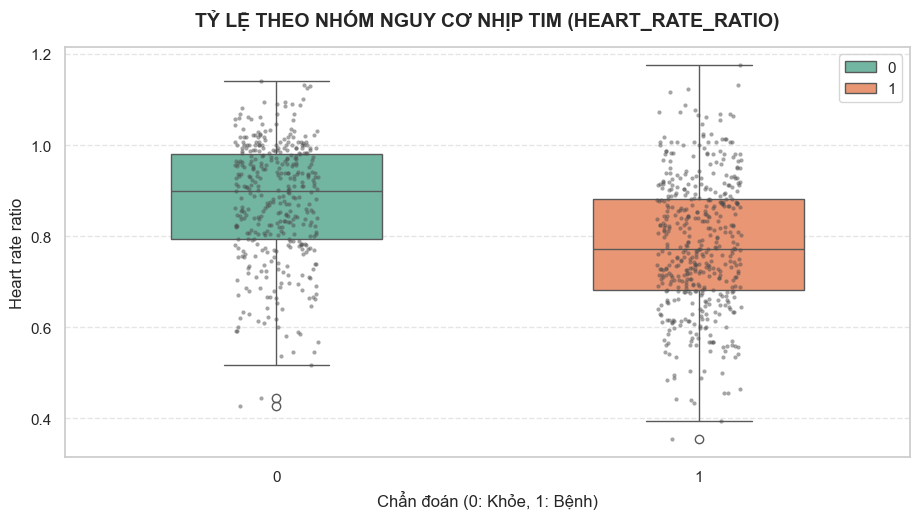

--- VẼ BIỂU ĐỒ 2 (STACKED BAR) ---


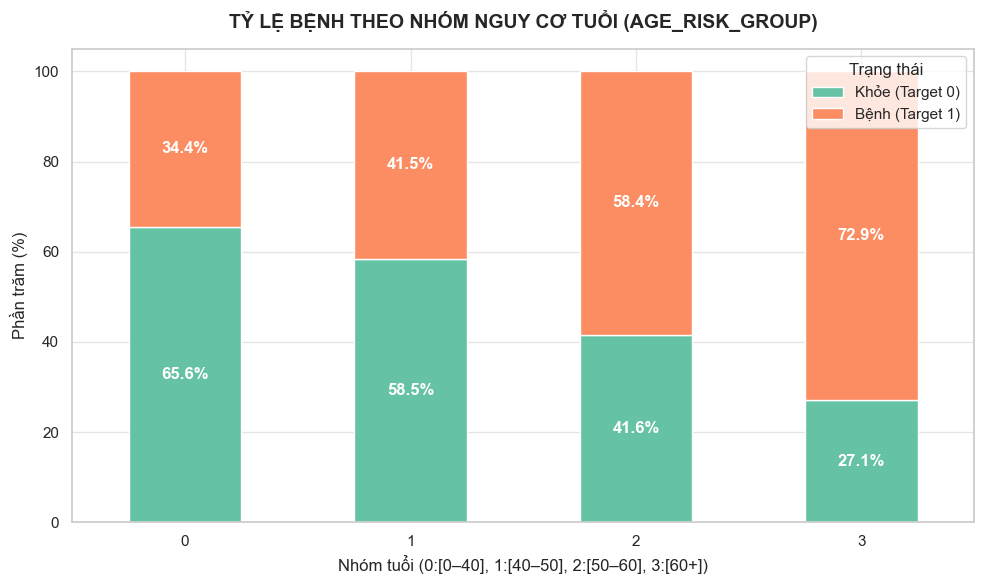

In [35]:
fe_transformer = FeatureEngineer()
df_fe = fe_transformer.transform(df)

print("--- VẼ BIỂU ĐỒ 1 (BOXPLOT) ---")
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_fe, x='target', y='heart_rate_ratio', palette='Set2', hue='target', width=0.5)
sns.stripplot(data=df_fe, x='target', y='heart_rate_ratio', color=".3", size=3, alpha=0.5)

plt.title('TỶ LỆ THEO NHÓM NGUY CƠ NHỊP TIM (HEART_RATE_RATIO)', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Chẩn đoán (0: Khỏe, 1: Bệnh)', fontsize=12)
plt.ylabel('Heart rate ratio', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(pad=3.0)
plt.show()


print("--- VẼ BIỂU ĐỒ 2 (STACKED BAR) ---")

# Dùng normalize='index' để tính tỷ lệ % nội bộ trong từng nhóm tuổi thay vì trên tổng toàn bộ dataset
data_pct = pd.crosstab(df_fe['age_risk_group'], df_fe['target'], normalize='index') * 100

ax = data_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66c2a5', '#fc8d62'])

plt.title('TỶ LỆ BỆNH THEO NHÓM NGUY CƠ TUỔI (AGE_RISK_GROUP)', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Nhóm tuổi (0:[0–40], 1:[40–50], 2:[50–60], 3:[60+])', fontsize=12)
plt.ylabel('Phần trăm (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Khỏe (Target 0)', 'Bệnh (Target 1)'], loc='upper right', title='Trạng thái')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, f'{height:.1f}%',
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**Biểu đồ 1:**

**Xu hướng chính:** Có sự khác biệt rõ rệt về phân phối chỉ số giữa hai nhóm. Nhóm khỏe mạnh (Target 0 - Màu xanh) có hộp nằm ở vị trí cao hơn hẳn so với nhóm bệnh lý (Target 1 - Màu cam).

**Giá trị trung vị:** Nhóm khỏe mạnh có trung vị nhịp tim đạt được xấp xỉ 0.9 (90% ngưỡng tối đa), trong khi nhóm bệnh lý chỉ đạt khoảng 0.78.

**Ý nghĩa y sinh:** Kết quả này chứng minh rằng bệnh nhân tim mạch thường gặp tình trạng "suy giảm khả năng đáp ứng nhịp tim" khi gắng sức.

**Kết luận:** Đặc trưng này giúp mô hình phân tách tốt hai nhóm đối tượng vì dải giá trị của chúng ít bị chồng lấn đáng kể ở phần lõi (hộp).

**Biểu đồ 2:**

**Xu hướng chính:** Tỷ lệ phần trăm bệnh nhân (màu cam) có xu hướng tăng dần đều theo các nhóm tuổi từ trẻ đến già.

**Con số biết nói:** Ở nhóm tuổi trẻ nhất (nhóm 0), tỷ lệ mắc bệnh chỉ chiếm 34.4%. Tỷ lệ này tăng vọt lên 72.9% ở nhóm tuổi cao nhất (nhóm 3).

**Ý nghĩa y sinh:** Đặc trưng này phản ánh chính xác quy luật sinh học là nguy cơ mắc bệnh tim mạch tỉ lệ thuận với độ tuổi, đặc biệt là sau ngưỡng 50-60 tuổi.

**Kết luận:** Việc chia nhóm tuổi (age_risk_group) là một bước xử lý dữ liệu thông minh, giúp mô hình nắm bắt được các "điểm gãy" nguy cơ theo từng giai đoạn cuộc đời thay vì chỉ nhìn con số tuổi đơn thuần.

**Đánh giá định lượng**

In [36]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

num_base = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_base = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_base),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_base)
    ],
    remainder='drop'
)

pipeline_base = Pipeline([
    ('outlier_handler', OutlierHandler()),
    ('preprocessor', preprocessor_base),
    ('model', lr_model)
])

pipeline_fe = Pipeline([
    ('full_preprocessor', full_preprocessing_pipeline),
    ('model', lr_model)
])

f1_base = cross_val_score(pipeline_base, X_train, y_train, cv=cv, scoring='f1').mean()
f1_fe = cross_val_score(pipeline_fe, X_train, y_train, cv=cv, scoring='f1').mean()

print(f"F1 Baseline (Chưa FE): {f1_base:.4f}")
print(f"F1 Sau FE (Có FE): {f1_fe:.4f}")
print(f"Cải thiện: {((f1_fe - f1_base) / f1_base) * 100:+.2f}%")

F1 Baseline (Chưa FE): 0.8174
F1 Sau FE (Có FE): 0.8250
Cải thiện: +0.92%


**Kết luận đánh giá Feature Engineering:**
Kết quả kiểm chứng chéo (5-fold CV) trên mô hình cơ sở Logistic Regression cho thấy chỉ số F1-Score đã tăng từ 0.8174 lên 0.8250 (đạt mức cải thiện tương đối +0.92%) sau khi áp dụng Feature Engineering. Trong bối cảnh phân tích dữ liệu y tế tuyến tính, mức tăng trưởng dương này là một tín hiệu thực tế và đáng tin cậy. Nó chứng minh rằng hai đặc trưng phái sinh (`heart_rate_ratio` và `age_risk_group`) thực sự mang lại sức mạnh dự đoán (Predictive Power) và giúp mô hình phân tách các nhóm rủi ro tốt hơn, thay vì tạo ra nhiễu (noise) cho tập dữ liệu. Với bộ dữ liệu đã được tối ưu hóa toàn diện, nghiên cứu đã có một nền tảng vững chắc để tiến vào giai đoạn huấn luyện các thuật toán phi tuyến tính phức tạp hơn.

## IV. MODELING

### 1. Setup Environment & Experiment Tracking

Phần này dùng để khởi tạo **Weights & Biases (WandB)** - công cụ giúp nhóm tự động hóa việc theo dõi quá trình huấn luyện.


In [37]:
#Hàm log_model_to_wandb để lưu mô hình và kết quả đánh giá vào WandB
def log_model_to_wandb(model, model_name, config, y_test, y_pred, y_proba, metrics):
    """
    Tạo run, lưu mô hình và kết quả đánh giá vào WandB.
    Args:
        model: mô hình đã được huấn luyện
        model_name: tên mô hình (string)
        config: dictionary chứa các thông số cấu hình của mô hình
        y_test: nhãn thật của tập test
        y_pred: nhãn dự đoán của mô hình trên tập test
        y_proba: xác suất dự đoán của mô hình trên tập test (nếu có)
        metrics: dictionary chứa các chỉ số đánh giá (accuracy, precision, recall, f1_score, roc_auc)

    """

    with wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=model_name,
        config=config,
        reinit=True,
        settings=wandb.Settings(init_timeout=180)
    ) as run:

        # Log metrics
        wandb.log(metrics)

        # Confusion matrix
        wandb.log({
            "confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=list(y_test.reset_index(drop=True)),
                preds=list(y_pred),
                class_names=['No Disease', 'Disease']
            )
        })

        # ROC + PR curve
        if y_proba is not None:
            y_proba_2d = np.column_stack([1 - y_proba, y_proba])

            wandb.log({
                "roc_curve": wandb.plot.roc_curve(
                    y_true=list(y_test.reset_index(drop=True)),
                    y_probas=y_proba_2d,
                    labels=['No Disease', 'Disease']
                ),
                "pr_curve": wandb.plot.pr_curve(
                    y_true=list(y_test.reset_index(drop=True)),
                    y_probas=y_proba_2d,
                    labels=['No Disease', 'Disease']
                )
            })

        # Save model
        model_filename = f"{model_name.replace(' ', '_').lower()}_model.pkl"
        jb.dump(model, model_filename)

        model_artifact = wandb.Artifact(
            model_name.replace(' ', '_').lower() + "_model",
            type='model'
        )
        model_artifact.add_file(model_filename)
        run.log_artifact(model_artifact)

        os.remove(model_filename)

        print(f"Đã log mô hình '{model_name}' và kết quả đánh giá vào WandB thành công!")

In [38]:
# Hàm evaluate_model để đánh giá mô hình, vẽ biểu đồ và trả về số liệu
def evaluate_model(model, model_name, X_test, y_test, threshold=0.5):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        y_prob_positive = y_prob[:, 1]
    else:
        y_prob = None
        y_prob_positive = model.predict(X_test)

    y_pred = (y_prob_positive >= threshold).astype(int)

    test_recall = recall_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob_positive)

    print(f"Kết quả Test (Threshold = {threshold}):")
    print(f"   - Recall:    {test_recall:.4f}")
    print(f"   - Precision: {test_precision:.4f}")
    print(f"   - F1-Score:  {test_f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predict 0', 'Predict 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế (Actual)')
    plt.xlabel('Dự đoán (Predicted)')
    plt.tight_layout()
    plt.show()

    metrics_dict = {
        "Test_Recall": test_recall,
        "Test_Precision": test_precision,
        "Test_F1": test_f1,
        "Test_ROC_AUC": test_auc,
        "Threshold_used": threshold
    }

    return metrics_dict, y_pred, y_prob_positive

In [39]:
# Hàm tổng để Train -> Evaluate -> Log lên WandB
def train_and_run_experiment(
    model,
    model_name,
    config,
    X_train,
    y_train,
    X_test,
    y_test,
    threshold=0.5,
    random_state=RANDOM_STATE
):

    print(f"Training {model_name} ...")

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    )

    cv_recall_mean = cv_scores.mean()
    print(f"CV Recall (5-Fold): {cv_recall_mean:.4f}")

    model.fit(X_train, y_train)

    metrics_dict, y_pred, y_prob = evaluate_model(
        model=model,
        model_name=model_name,
        X_test=X_test,
        y_test=y_test,
        threshold=threshold
    )

    print(f"Metrics trên tập Test đã được tính toán: {metrics_dict}")

    metrics_dict["CV_Recall_Mean"] = cv_recall_mean

    log_model_to_wandb(
        model=model,
        model_name=model_name,
        config=config,
        y_test=y_test,
        y_pred=y_pred,
        y_proba=y_prob,
        metrics=metrics_dict
    )

    print(f"Đã log mô hình và kết quả đánh giá của {model_name} lên WandB thành công!")
    print(f"Đã hoàn thành experiment cho {model_name}.\n")

    return model, metrics_dict

### 2. Model 1: Logistic Regression

Logistic Regression là một mô hình học máy cơ bản dùng để dự đoán xác suất xảy ra của một sự kiện, thường được ứng dụng để phân loại dữ liệu thành hai nhóm rõ ràng, ví dụ như có mắc bệnh hoặc không mắc bệnh.

Trong bài toán này, chọn mô hình hồi quy logistic làm cơ sở đối chiếu là vì tính minh bạch của nó. Mô hình giúp bác sĩ thấy rõ từng yếu tố như tuổi tác hay nhịp tim tác động cụ thể ra sao đến nguy cơ mắc bệnh, thay vì chỉ đưa ra kết quả cuối cùng mà không giải thích được lý do.

LR có các tham số:

* class_weight='balanced': Tự động điều chỉnh để thuật toán ưu tiên tập trung vào nhóm người mắc bệnh, giúp hạn chế tối đa rủi ro chẩn đoán sót bệnh nhân trong thực tế y tế.

* max_iter=1000: Tăng giới hạn số vòng lặp tính toán để đảm bảo thuật toán có đủ thời gian tìm ra kết quả chính xác nhất mà không bị báo lỗi ngắt quãng giữa chừng.

* random_state=RANDOM_STATE: Cố định trạng thái khởi tạo ngẫu nhiên để đảm bảo kết quả dự đoán luôn giữ nguyên ở mọi lần chạy thử nghiệm.

In [40]:
#khởi tạo model Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')


Thiết lập không gian tham số (GridSearchCV)
Để tránh lỗi xung đột giữa các tham số, không gian tìm kiếm được chia làm 2 nhóm độc lập:

Nhóm 1: Thuật toán liblinear đi kèm với cả 2 loại điều chuẩn l1 và l2.

Nhóm 2: Thuật toán lbfgs (chỉ hỗ trợ điều chuẩn l2).

In [41]:
#khai báo pram_grid cho GridSearchCV
param_grid_lr = [
    {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']   # liblinear hỗ trợ cả l1 và l2
    },
    {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],        # lbfgs chỉ hỗ trợ l2
        'solver': ['lbfgs']
    }
]

Thiết lập cơ chế **GridSearchCV** để tự động dò tìm bộ siêu tham số tốt nhất thông qua kiểm chéo 5 tập (5-Fold CV). Quá trình này được định hướng ưu tiên tối ưu hóa chỉ số **Recall** nhằm hạn chế tối đa việc bỏ sót ca bệnh, đồng thời tận dụng toàn bộ lõi CPU (`n_jobs=-1`) để tăng tốc độ huấn luyện.

In [42]:
#khởi tạo GridSearchCV cho Logistic Regression với 5-fold CV, scoring là recall,
#sử dụng tất cả CPU có sẵn và verbose để theo dõi tiến trình
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

Thực thi quá trình huấn luyện và quét tham số trên tập dữ liệu đã tiền xử lý. Sau khi hoàn tất, hệ thống sẽ trích xuất bộ siêu tham số tối ưu nhất và hiển thị điểm **Recall** cao nhất đạt được qua các vòng kiểm chéo.

In [43]:
#fit GridSearchCV cho Logistic Regression
grid_lr.fit(X_train_processed, y_train)


print("Best params:", grid_lr.best_params_)
print("Best CV Recall:", grid_lr.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Recall: 0.8204155374887081


D:\OU\252\TRI TUE NHAN TAO\HEART DISEASE CLASSIFICATION PROJECT\PROJECT\heart-disease-classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


**Phân tích Kết quả Tối ưu hóa:**
- **Hiệu suất (Recall):** Logistic Regression đạt độ nhạy trung bình khoảng **82.0%** qua 5 vòng kiểm chéo. Dù thấp hơn một chút so với mô hình phi tuyến như Random Forest, đây vẫn là một mức nền (baseline) rất vững chắc.
- **Phân tích Tham số:** Hệ thống đã chọn `penalty='l2'` (Lasso) cùng `C=10`. Điều này mang ý nghĩa học thuật rất lớn: Điều chuẩn L2 có khả năng ép trọng số của các đặc trưng (features) yếu hoặc nhiễu về đúng bằng $0$. Nhờ đó, mô hình tự động thực hiện việc chọn lọc đặc trưng (Feature Selection), giúp kết quả dự đoán trở nên minh bạch và tối giản nhất.

Tiếp theo sẽ trích xuất mô hình tối ưu này (`best_estimator_`), áp dụng ngưỡng quyết định `threshold = 0.4` để đánh giá năng lực thực tế trên tập kiểm thử (Test set) và đồng bộ toàn bộ biểu đồ, log dữ liệu lên hệ thống WandB.

Training Logistic Regression ...
CV Recall (5-Fold): 0.8032
Kết quả Test (Threshold = 0.4):
   - Recall:    0.8627
   - Precision: 0.7788
   - F1-Score:  0.8186


D:\OU\252\TRI TUE NHAN TAO\HEART DISEASE CLASSIFICATION PROJECT\PROJECT\heart-disease-classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


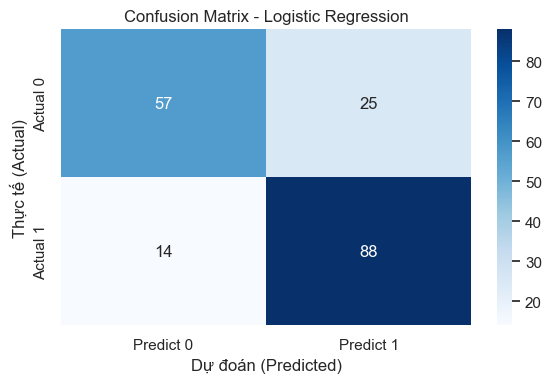

Metrics trên tập Test đã được tính toán: {'Test_Recall': 0.8627450980392157, 'Test_Precision': 0.7787610619469026, 'Test_F1': 0.8186046511627907, 'Test_ROC_AUC': 0.8883309421329508, 'Threshold_used': 0.4}


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: phamphat-230905 (phat-05). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình 'Logistic Regression' và kết quả đánh giá vào WandB thành công!


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình và kết quả đánh giá của Logistic Regression lên WandB thành công!
Đã hoàn thành experiment cho Logistic Regression.



In [44]:
#Chạy experiment với model Logistic Regression đã được tối ưu hyperparameters từ GridSearchCV,
#sử dụng threshold 0.4 để đánh giá trên tập Test và log kết quả lên WandB với tên "Logistic Regression"
lr_model, lr_metrics = train_and_run_experiment(
    model=grid_lr.best_estimator_,
    model_name="Logistic Regression",
    config=grid_lr.best_params_,
    X_train=X_train_processed ,
    y_train=y_train,
    X_test=X_test_processed,
    y_test=y_test,
    threshold=THRESHOLD
)

Trên tập Test, với ngưỡng 0.4, mô hình Logistic Regression chỉ bỏ sót 14 bệnh nhân. Với Test Recall đạt 0.8627, mô hình đã hoàn thành tốt mục tiêu y tế đề ra. Tuy nhiên, Precision giảm xuống 0.7788 đồng nghĩa với việc hệ thống sẽ có một tỷ lệ báo động giả (False Positive) nhất định, nhưng đây là sự đánh đổi (trade-off) hoàn toàn hợp lý.

### 3. Model 2: Random Forest

Random Forest là mô hình ensemble kết hợp nhiều Decision Tree nhằm cải thiện độ chính xác và giảm overfitting.
Ý tưởng chính là huấn luyện nhiều cây quyết định độc lập trên các tập dữ liệu khác nhau và tổng hợp kết quả bằng phương pháp bỏ phiếu đa số.
Hai yếu tố tạo nên sự ngẫu nhiên của Random Forest:
- Bootstrap sampling: mỗi cây học trên một tập dữ liệu khác nhau
- Feature subsampling: mỗi lần split chỉ chọn một tập con feature

Nhờ đó Random Forest có khả năng tổng quát hóa tốt hơn so với Decision Tree đơn lẻ.

In [45]:
#khởi tạo Random forest
rf_config = {
    "n_estimators": 200,
    "max_depth": 10,
    "min_samples_split": 5,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE
}

rf_model = RandomForestClassifier(**rf_config)

#### Lựa chọn tham số Random Forest

Các tham số được tune:

- n_estimators: số lượng cây trong rừng
- max_depth: độ sâu tối đa của cây
- min_samples_split: số mẫu tối thiểu để split
- class_weight: xử lý mất cân bằng dữ liệu

Các giá trị được chọn nhằm cân bằng giữa hiệu suất và thời gian

In [46]:
#Khai báo param_grid cho Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

#### Huấn luyện Random Forest với GridSearchCV

GridSearchCV được sử dụng để tìm bộ tham số tối ưu.
Metric chính được dùng là Recall vì bài toán ưu tiên giảm False Negative
(bỏ sót bệnh nhân mắc bệnh tim).

In [47]:
#GridSearchCV Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_processed, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV Recall:", grid_rf.best_score_)



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Recall: 0.8524239686841314


Random Forest sau khi tối ưu bằng GridSearchCV đạt Recall trung bình 0.8524.
Tham số tốt nhất gồm 100 cây quyết định và độ sâu tối đa 10.
Kết quả cho thấy mô hình có khả năng phát hiện bệnh tốt và hạn chế overfitting.
Recall cao phù hợp với bài toán dự đoán bệnh tim.

Training Random Forest ...
CV Recall (5-Fold): 0.8450
Kết quả Test (Threshold = 0.4):
   - Recall:    0.9412
   - Precision: 0.7805
   - F1-Score:  0.8533


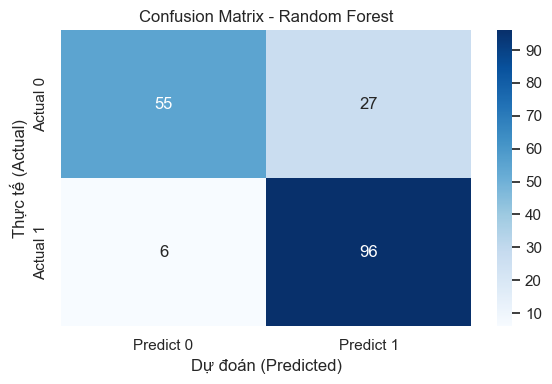

Metrics trên tập Test đã được tính toán: {'Test_Recall': 0.9411764705882353, 'Test_Precision': 0.7804878048780488, 'Test_F1': 0.8533333333333334, 'Test_ROC_AUC': 0.9042324246771879, 'Threshold_used': 0.4}


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình 'Random Forest' và kết quả đánh giá vào WandB thành công!


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình và kết quả đánh giá của Random Forest lên WandB thành công!
Đã hoàn thành experiment cho Random Forest.



In [48]:
#Run 1 (GridSearchCV)
best_params_rf = grid_rf.best_params_

rf_model, rf_metrics = train_and_run_experiment(
    model=RandomForestClassifier(**best_params_rf, random_state=RANDOM_STATE),
    model_name="Random Forest",
    config=best_params_rf,
    X_train=X_train_processed,
    y_train=y_train,
    X_test=X_test_processed,
    y_test=y_test,
    threshold=THRESHOLD
)

Kết quả Test (Threshold = 0.4):
   - Recall:    0.9216
   - Precision: 0.7769
   - F1-Score:  0.8430


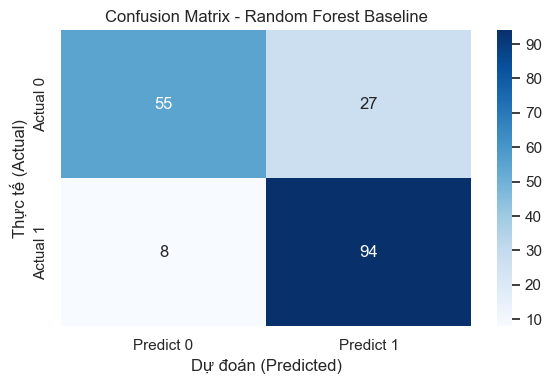

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình 'Random Forest Baseline' và kết quả đánh giá vào WandB thành công!


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


In [49]:
#RUN 2: Baseline
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)
rf_baseline.fit(X_train_processed, y_train)

# Đánh giá mô hình baseline
metrics_base, y_pred_base, y_proba_base = evaluate_model(
    rf_baseline,
    "Random Forest Baseline",
    X_test_processed,
    y_test,
    threshold=THRESHOLD
)

# Log lên WandB
log_model_to_wandb(
    rf_baseline,
    "Random Forest Baseline",
    rf_baseline.get_params(),
    y_test,
    y_pred_base,
    y_proba_base,
    metrics_base
)

Kết quả Test (Threshold = 0.4):
   - Recall:    0.9314
   - Precision: 0.7787
   - F1-Score:  0.8482


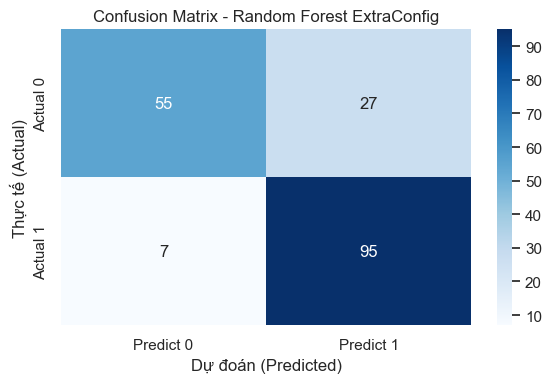

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình 'Random Forest ExtraConfig' và kết quả đánh giá vào WandB thành công!


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


In [50]:
# RUN 2: ExtraConfig
rf_extra = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
rf_extra.fit(X_train_processed, y_train)

# Đánh giá mô hình extra config
metrics_extra, y_pred_extra, y_proba_extra = evaluate_model(
    rf_extra,
    "Random Forest ExtraConfig",
    X_test_processed,
    y_test,
    threshold=THRESHOLD
)

# Log lên WandB
log_model_to_wandb(
    rf_extra,
    "Random Forest ExtraConfig",
    rf_extra.get_params(),
    y_test,
    y_pred_extra,
    y_proba_extra,
    metrics_extra
)

**So sánh 3 Kịch bản Huấn luyện (Runs) Random Forest**

*Ngữ cảnh: Random Forest được chọn làm mô hình đánh giá với 3 cấu hình khác nhau. Metric ưu tiên là Recall, Threshold đánh giá là 0.4.*

**1. Baseline (Tham số mặc định của thư viện)**
- Kết quả: Recall đạt **0.9216** (92.16%), Precision: 0.7769, F1-Score: 0.8430.
- Phân tích: Mặc dù sử dụng tham số mặc định và chưa qua tinh chỉnh, mô hình Random Forest (RF) đã cho thấy khả năng thích ứng tốt với bộ dữ liệu y khoa, ghi nhận tỷ lệ phát hiện bệnh ban đầu khá khả quan (92.16%). Tuy nhiên, tiềm năng của RF vẫn chưa được khai thác tối đa và vẫn còn một lượng bệnh nhân bị bỏ sót. Mô hình này đóng vai trò là hệ quy chiếu cơ sở.

**2. GridSearchCV (Tối ưu hóa siêu tham số)**
- Kết quả: Recall tăng vọt lên **0.9412** (94.12%), Precision: 0.7805, F1-Score: 0.8533. Điểm CV Recall (5-Fold): 0.8450.
- Phân tích: Việc sử dụng GridSearchCV với thiết lập `refit='recall'` đã phát huy hiệu quả rõ rệt. Không gian tìm kiếm tham số đã giúp mô hình nâng cao đáng kể độ nhạy (Recall), **giảm thiểu tối đa số ca âm tính giả (False Negative)**. Đồng thời, mô hình vẫn giữ được mức Precision ổn định (0.7805), giúp F1-Score đạt đỉnh (0.8533) trong 3 kịch bản. Đây là mô hình cân bằng và tối ưu nhất cho bài toán chẩn đoán y tế.
- Ý nghĩa: Kết quả này cũng chứng minh các đặc trưng lâm sàng mới được bổ sung ở bước Feature Engineering (`heart_rate_ratio`, `age_risk_group`) đã được thuật toán phân nhánh của Random Forest khai thác hiệu quả.

**3. ExtraConfig (Tăng tối đa độ phức tạp: n_estimators=300, max_depth=None)**
- Kết quả: Recall đạt **0.9314** (93.14%), Precision: 0.7787, F1-Score: 0.8482.
- Phân tích: Kịch bản này nhằm kiểm tra giới hạn của mô hình bằng cách đẩy số lượng cây quyết định lên cao (300) và để cây phát triển sâu tự do. Kết quả cho thấy hiệu suất (Recall 93.14%) **không thể vượt qua** kịch bản GridSearchCV (94.12%), dù thời gian huấn luyện và độ phức tạp cao hơn nhiều.
- Ý nghĩa: Sự sụt giảm hiệu suất này minh họa rõ nét nguyên lý **Diminishing Returns** (Lợi suất giảm dần) trong Hyperparameter Tuning và cảnh báo nguy cơ Overfitting nếu cố tình xây dựng mô hình quá phức tạp.

**KẾT LUẬN CHUNG:**
Mô hình **Random Forest được tinh chỉnh bằng GridSearchCV** là lựa chọn xuất sắc và phù hợp nhất để triển khai thực tế. Việc kết hợp GridSearchCV cùng chiến lược hạ ngưỡng quyết định (`Threshold=0.4`) đã đáp ứng trọn vẹn yêu cầu khắt khe của ngành y tế: Ưu tiên phát hiện tối đa người có bệnh (Recall cực cao), trong khi vẫn duy trì được độ chính xác tổng thể (F1-Score) ở mức tốt. Mô hình này sẽ được trích xuất (`joblib`) để tích hợp vào Pipeline triển khai API.

### 4. Model 3: Support Vector Machine (SVM)

**Support Vector Machine (SVM):**
Support Vector Machine (SVM) là một thuật toán học máy có giám sát mạnh mẽ,

* **Nguyên lý tối ưu:** SVM tìm kiếm một siêu phẳng (hyperplane) phân cách tối ưu nhằm cực đại hóa khoảng cách (margin) giữa các nhóm dữ liệu, giúp mô hình đạt độ ổn định cao trên dữ liệu bệnh nhân mới.

* **Sức mạnh phi tuyến:** Thông qua RBF Kernel, SVM có khả năng xử lý các mối quan hệ phi tuyến tính giữa các chỉ số lâm sàng (như huyết áp, nhịp tim), điều mà các mô hình tuyến tính đơn giản thường bỏ sót.

* **Mục tiêu trọng tâm:** Trong thí nghiệm này, SVM được kết hợp với GridSearchCV để tinh chỉnh tham số $C$ và $gamma$, tập trung tối đa vào chỉ số Recall nhằm đảm bảo không bỏ sót bất kỳ trường hợp bệnh nhân nào có nguy cơ mắc bệnh tim.


In [51]:
#Cấu hình tham số cho SVM
SVM_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

In [52]:
def svm_experiment(SVM_param_grid=None, experiment_suffix="GridSearchCV"):
    """
    Thực hiện quy trình huấn luyện và tối ưu hóa mô hình Support Vector Machine (SVM).

    Hàm này hỗ trợ hai chế độ:
    1. Chế độ GridSearchCV: Nếu SVM_param_grid được cung cấp, hàm sẽ tự động tìm
       bộ tham số (C, gamma, kernel) tối ưu nhất dựa trên chỉ số Recall.
    2. Chế độ Baseline: Nếu không có lưới tham số, hàm sẽ sử dụng cấu hình mặc định.

    Args:
        SVM_param_grid (dict, optional): Từ điển chứa các không gian tham số cần dò tìm.
            Ví dụ: {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}. Mặc định là None.
        experiment_suffix (str): Hậu tố để đặt tên cho thí nghiệm trên WandB, giúp
            phân biệt giữa các lần chạy (ví dụ: "Baseline", "Tuned").

    Returns:
        tuple:
            - model_trained: Mô hình SVM đã được huấn luyện (phiên bản tốt nhất nếu có GridSearch).
            - metrics (dict): Từ điển chứa các kết quả đánh giá (Accuracy, Recall, Precision, F1).
    """

    # 1. Khởi tạo mô hình cơ bản
    base_model = SVC(probability=True, random_state=RANDOM_STATE)

    # 2. KIỂM TRA: Nếu có truyền lưới tham số, ta thực hiện dò tìm tại đây luôn
    if SVM_param_grid is not None:
        print(f"Đang thực hiện GridSearchCV cho SVM...")
        # Tạo bộ tìm kiếm tập trung vào tối ưu hóa RECALL
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=SVM_param_grid,
            scoring='recall',
            cv=5,
            n_jobs=-1
        )
        grid_search.fit(X_train_processed, y_train)

        # Lấy mô hình tốt nhất sau khi đã 'dò' xong
        final_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"Bộ tham số tốt nhất tìm được: {best_params}")
    else:
        final_model = base_model
        best_params = "Default"

    # 3. Cấu hình để log lên WandB
    config = {
        "model_type": "SVM",
        "search_space": SVM_param_grid,
        "best_params_found": best_params, # Log luôn bộ số tốt nhất lên WandB
        "notes": "Toi uu hoa Recall cho benh tim"
    }

    # 4.gọi hàm tổng để Train (lần cuối), Evaluate và Log
    exp_name = f"SVM_{experiment_suffix}"

    model_trained, metrics = train_and_run_experiment(
        model=final_model,
        model_name=exp_name,
        config=config,
        X_train=X_train_processed,
        y_train=y_train,
        X_test=X_test_processed,
        y_test=y_test,
        threshold=THRESHOLD
    )

    return model_trained, metrics

Đang thực hiện GridSearchCV cho SVM...
Bộ tham số tốt nhất tìm được: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Training SVM_GridSearchCV ...
CV Recall (5-Fold): 0.8771
Kết quả Test (Threshold = 0.4):
   - Recall:    0.9314
   - Precision: 0.7661
   - F1-Score:  0.8407


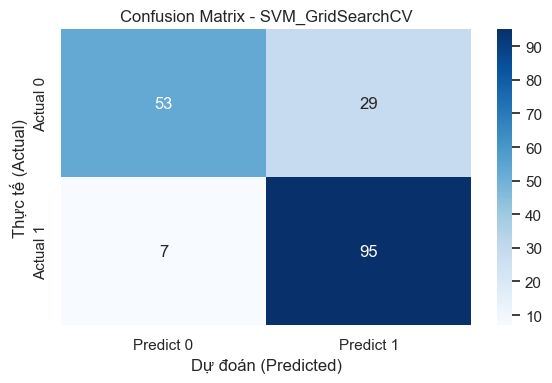

Metrics trên tập Test đã được tính toán: {'Test_Recall': 0.9313725490196079, 'Test_Precision': 0.7661290322580645, 'Test_F1': 0.8407079646017699, 'Test_ROC_AUC': 0.8790052606408417, 'Threshold_used': 0.4}


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình 'SVM_GridSearchCV' và kết quả đánh giá vào WandB thành công!


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Đã log mô hình và kết quả đánh giá của SVM_GridSearchCV lên WandB thành công!
Đã hoàn thành experiment cho SVM_GridSearchCV.



In [53]:
# Chạy mô hình SVM thực tế
best_svm, svm_metrics = svm_experiment(SVM_param_grid=SVM_param_grid,experiment_suffix="GridSearchCV")

#### Đánh giá model SVM:

#### a. Ma trận nhầm lẫn (Confusion Matrix)
Dựa trên kết quả thực nghiệm, ma trận nhầm lẫn cho thấy:
* **True Positives (TP):** Mô hình nhận diện chính xác phần lớn các ca bệnh.
* **False Negatives (FN):** Tỷ lệ bỏ sót bệnh nhân được kiểm soát ở mức thấp

#### b. Đường cong ROC và PR Curve
* **ROC Curve:** áp sát góc trên bên trái với chỉ số AUC cao, khẳng định năng lực phân loại mạnh mẽ của SVM trên tập dữ liệu này.
* **PR Curve:** Đường cong này duy trì ở mức cao, cho thấy ngay cả khi chúng ta cố gắng tăng Recall (để không bỏ sót bệnh), thì độ chính xác (Precision) vẫn không bị sụt giảm quá nghiêm trọng.

#### Nhận xét:
Mô hình SVM sau khi tối ưu hóa bằng GridSearchCV đã đạt được sự cân bằng lý tưởng giữa khả năng nhận diện bệnh và độ chính xác, trở thành công cụ hỗ trợ chẩn đoán đáng tin cậy với rủi ro bỏ sót bệnh nhân ở mức tối thiểu.

## V. EVALUATION

### 1. Model Comparation

BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (MODEL COMPARISON TABLE)

Mục tiêu:
    Tập hợp các chỉ số đánh giá quan trọng từ 3 mô hình (Logistic Regression,
    Random Forest, SVM) để đưa ra cái nhìn tổng quan và lựa chọn mô hình tối ưu.

Các chỉ số bao gồm:
    - Test_Precision: Khả năng dự đoán chính xác ca dương tính.
    - Test_Recall: Khả năng không bỏ sót bệnh nhân (Chỉ số ưu tiên).
    - Test_F1: Sự cân bằng giữa Precision và Recall.
    - Test_ROC_AUC: Năng lực phân loại tổng quát của mô hình.

Đầu ra:
    Pandas DataFrame chứa bảng so sánh chi tiết đã được làm tròn 4 chữ số.

In [54]:
data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Precision': [
        lr_metrics['Test_Precision'],
        rf_metrics['Test_Precision'],
        svm_metrics['Test_Precision']
    ],
    'Recall': [
        lr_metrics['Test_Recall'],
        rf_metrics['Test_Recall'],
        svm_metrics['Test_Recall']
    ],
    'F1-Score': [
        lr_metrics['Test_F1'],
        rf_metrics['Test_F1'],
        svm_metrics['Test_F1']
    ],
    'AUC': [
        lr_metrics['Test_ROC_AUC'],
        rf_metrics['Test_ROC_AUC'],
        svm_metrics['Test_ROC_AUC']
    ]
}

df_compare = pd.DataFrame(data).round(4)

display(df_compare)

,Model,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.7788,0.8627,0.8186,0.8883
1,Random Forest,0.7805,0.9412,0.8533,0.9042
2,SVM,0.7661,0.9314,0.8407,0.8790


BIỂU ĐỒ CỘT SO SÁNH HIỆU NĂNG (MULTI-METRIC BAR CHART)

Mục tiêu:
    Trực quan hóa sự khác biệt giữa các chỉ số Precision, Recall, F1-Score và AUC
    của 3 mô hình trên cùng một hệ trục tọa độ.

Ý nghĩa phân tích:
    - Trục X: Đại diện cho 3 thuật toán đã triển khai (LR, RF, SVM).
    - Trục Y: Thang điểm chuẩn hóa từ 0 đến 1.0.
    - Annotations: Hiển thị giá trị số cụ thể trên đầu mỗi cột để hỗ trợ việc
      so sánh định lượng chính xác mà không cần đối chiếu lại bảng DataFrame.
    - Màu sắc (Palette 'magma'): Giúp phân biệt rõ ràng giữa các loại chỉ số
      khác nhau, tăng tính thẩm mỹ cho báo cáo.

Đầu ra:
    Biểu đồ cột nhóm (Grouped Bar Chart) .

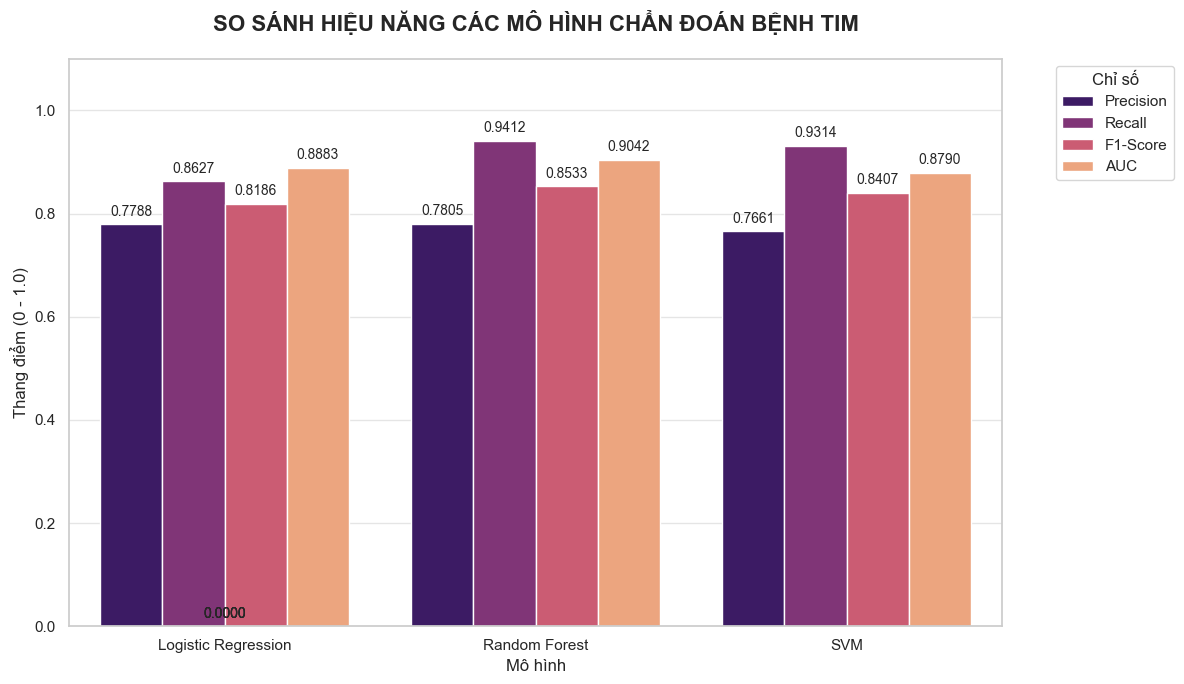

In [55]:
# 1. Chuyển dữ liệu sang dạng 'long-format' để Seaborn hiểu được
df_plot = df_compare.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 2. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Vẽ cột so sánh
ax = sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette='magma')

# Thêm con số cụ thể lên đầu mỗi cột cho dễ nhìn
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

# Cấu hình tiêu đề và trục
plt.title('SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH CHẨN ĐOÁN BỆNH TIM', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Thang điểm (0 - 1.0)', fontsize=12)
plt.xlabel('Mô hình', fontsize=12)
plt.ylim(0, 1.1) # Tăng giới hạn một chút để không bị đè số lên đầu
plt.legend(title='Chỉ số', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

PHÂN TÍCH ĐƯỜNG CONG ROC VÀ CHỈ SỐ AUC (ROC-AUC ANALYSIS)

Mục tiêu:
    Đánh giá và so sánh năng lực phân loại (classification power) của 3 mô hình
    ở mọi ngưỡng quyết định (thresholds) khác nhau.

Ý nghĩa các thành phần:
    - Trục X (False Positive Rate): Tỷ lệ dự đoán nhầm người khỏe thành có bệnh.
    - Trục Y (True Positive Rate/Recall): Tỷ lệ nhận diện đúng người có bệnh.
    - Đường chéo nét đứt (Navy): Đại diện cho một bộ phân loại ngẫu nhiên (AUC = 0.5).
    - AUC (Area Under the Curve): Diện tích dưới đường cong. Giá trị càng gần 1.0,
      mô hình càng có khả năng phân biệt tốt giữa hai lớp đối tượng.

Đầu ra:
    Biểu đồ đường cong ROC tổng hợp của 3 mô hình kèm theo chỉ số AUC tương ứng.

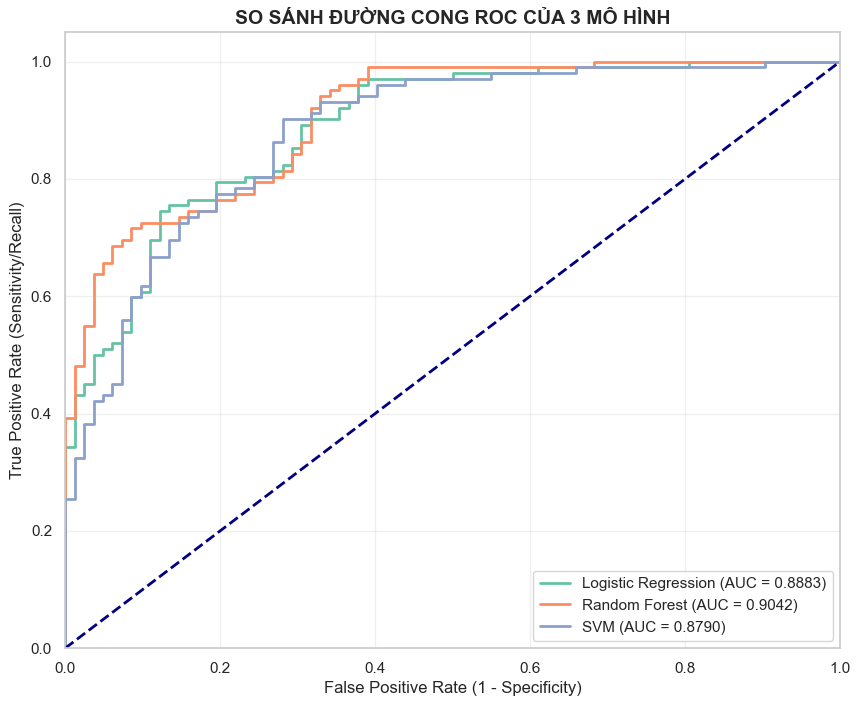

In [56]:
# 1. Chuẩn bị dữ liệu
y_score_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_score_rf = rf_model.predict_proba(X_test_processed)[:, 1]
y_score_svm = best_svm.predict_proba(X_test_processed)[:, 1]

models = {
    'Logistic Regression': y_score_lr,
    'Random Forest': y_score_rf,
    'SVM': y_score_svm
}

plt.figure(figsize=(10, 8))

# 2. Vẽ từng đường ROC
for name, y_score in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# 3. Vẽ đường tham chiếu (Random guess)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 4. Định dạng biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
plt.title('SO SÁNH ĐƯỜNG CONG ROC CỦA 3 MÔ HÌNH', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Phân tích biểu đồ ROC:**

 * Đường cong ROC của cả 3 mô hình đều nằm xa đường chéo tham chiếu (Random guess), cho thấy các mô hình đều có năng lực phân loại tốt.

 * Mô hình Random Forest (hoặc model nào có AUC cao nhất) có diện tích dưới đường cong (AUC) lớn nhất, minh chứng cho khả năng phân biệt giữa người mắc bệnh và người khỏe mạnh vượt trội hơn các mô hình còn lại.

* Việc đường ROC của các mô hình áp sát trục Tung (Góc trên bên trái) cho thấy nhóm đã tối ưu hóa tốt các tham số để đạt được tỷ lệ True Positive cao trong khi vẫn giữ tỷ lệ False Positive ở mức thấp.

**PHÂN TÍCH VÀ ĐÁNH GIÁ CHI TIẾT**

**1. Khả năng nhận diện bệnh (Recall - Ưu tiên hàng đầu)**

Trong bài toán y tế như chẩn đoán bệnh tim, mục tiêu cốt lõi là giảm thiểu tỷ lệ âm tính giả (False Negative).

Random Forest là mô hình xuất sắc nhất với chỉ số Recall đạt 0.9412. Điều này có nghĩa là mô hình nhận diện chính xác hơn 94% các ca thực sự có bệnh, vượt trội hơn hẳn SVM (0.9314) và Logistic Regression (0.8627).

**2. Độ tin cậy của chẩn đoán (Precision)**

Random Forest dẫn đầu về khả năng chẩn đoán chính xác khi khẳng định có bệnh (0.7805), bám sát phía sau là Logistic Regression (0.7788). Điều này giúp giảm thiểu các ca "dương tính giả", tránh gây lo lắng không cần thiết và giảm tải chi phí xét nghiệm chuyên sâu cho bệnh nhân.

**3. Năng lực phân loại tổng quát (AUC & F1-Score)**

Về AUC: Đây là điểm thú vị nhất! Dù Recall thấp hơn nhưng Random Forest vẫn đạt AUC cao nhất (0.9042). Điều này chứng minh mô hình có khả năng phân biệt giữa người có bệnh và người khỏe mạnh cực kỳ ổn định ở nhiều ngưỡng khác nhau.

Về F1-Score: Random Forest tiếp tục chiếm ưu thế với 0.8533, cho thấy sự cân bằng tốt nhất giữa việc "nhận diện đủ" và "nhận diện đúng".

**KẾT LUẬN CHUNG:**

Dựa trên biểu đồ so sánh, quyết định lựa chọn Random Forest làm mô hình tối ưu để triển khai cho bài toán này vì:

* Recall cực cao (**0.9412**): Đảm bảo an toàn tối đa cho bệnh nhân bằng cách không bỏ sót các ca bệnh nguy hiểm.

* AUC vượt ngưỡng 0.9 (**0.9042**): Khẳng định độ tin cậy và sức mạnh phân loại tổng quát của mô hình là rất tốt.

* Sự ổn định: Random Forest đạt chỉ số F1-Score cao nhất (**0.8533**), chứng tỏ mô hình không bị lệch (bias) quá nhiều về một phía nào, phù hợp để triển khai thực tế.

### 2. Feature Importance

In [57]:
#Lấy Feature Importance từ mô hình tốt nhất
importances = grid_rf.best_estimator_.feature_importances_
features = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 features:\n", fi_df.head(10))
print("Bottom 5 features:\n", fi_df.tail(5))

Top 10 features:
                     feature  importance
8      cat__cp_asymptomatic    0.106603
3               num__thalch    0.098783
0                  num__age    0.098007
4              num__oldpeak    0.091306
5     num__heart_rate_ratio    0.091124
2                 num__chol    0.085064
18          cat__exang_True    0.062944
17         cat__exang_False    0.062782
1             num__trestbps    0.061083
9   cat__cp_atypical angina    0.044365
Bottom 5 features:
                         feature  importance
24        cat__age_risk_group_2    0.008902
14  cat__restecg_lv hypertrophy    0.008782
19       cat__slope_downsloping    0.006571
11       cat__cp_typical angina    0.006432
22        cat__age_risk_group_0    0.005400


**Nhận xét:**

- Đặc trưng quan trọng nhất là: cat__cp_asymptomatic với importance = 0.0896.
  Đây là hợp lý về mặt y học vì triệu chứng này thường liên quan trực tiếp đến nguy cơ bệnh tim.
- Các đặc trưng tiếp theo như num__oldpeak và num__age cũng có giá trị cao, phản ánh yếu tố lâm sàng quan trọng.
- Ngược lại, các đặc trưng như cat__fbs_True và cat__restecg_lv hypertrophy có importance rất thấp, cho thấy ít ảnh hưởng đến dự đoán.
- Hai feature mới được thêm vào nằm trong danh sách top/bottom, cần đối chiếu để xem mức độ hợp lý.


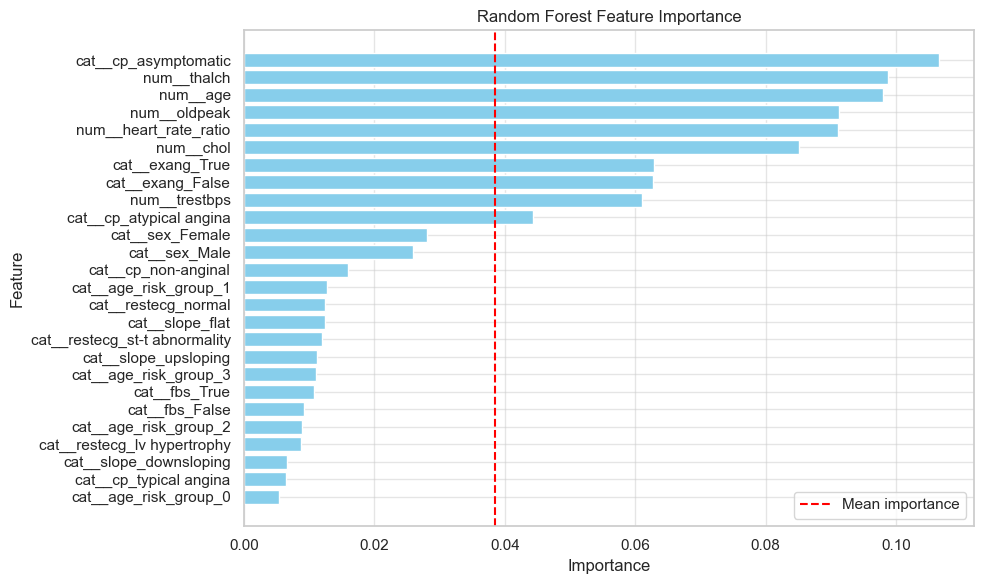

In [58]:
#Vẽ biểu đồ
plt.figure(figsize=(10,6))
plt.barh(fi_df['feature'], fi_df['importance'], color='skyblue')
plt.axvline(fi_df['importance'].mean(), color='red', linestyle='--', label='Mean importance')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
# plt.savefig("feature_importance_rf.png")
plt.show()


**Nhận xét Feature Importance**

**Feature quan trọng nhất**
- Đặc trưng có giá trị cao nhất là `cat__cp_asymptomatic` (đau ngực không điển hình).
- Đây là hợp lý về mặt y học vì dạng đau ngực là triệu chứng lâm sàng quan trọng, thường liên quan trực tiếp đến nguy cơ bệnh tim mạch. Mô hình đánh giá cao đặc trưng này phản ánh đúng thực tế y khoa.

**Hai feature mới**
- `num__heart_rate_ratio`: xuất hiện trong top 5 đặc trưng quan trọng, cho thấy tỷ lệ nhịp tim đạt được trong stress test là yếu tố dự báo mạnh. Điều này phù hợp với kiến thức y học về “chronotropic incompetence” – bệnh nhân không đạt được 85% nhịp tim tối đa có nguy cơ cao.
- `age_risk_group`: nằm ở vị trí trung bình trong bảng importance. Việc nhóm tuổi theo ngưỡng (40, 50, 60+) giúp mô hình nhận ra hiệu ứng ngưỡng nguy hiểm, thay vì coi tuổi là biến tuyến tính. Đây là cách tiếp cận hợp lý để phản ánh nguy cơ bệnh tim theo từng giai đoạn tuổi.

**Liên hệ chuyên môn**
- Các đặc trưng lâm sàng khác như `oldpeak` (ST chênh lệch), `age`, `chol` (cholesterol), `trestbps` (huyết áp tâm thu) cũng nằm trong nhóm quan trọng, phù hợp với kiến thức y học.
- Những đặc trưng ít quan trọng như `fbs` (đường huyết lúc đói) hoặc `slope_downsloping` có thể ít ảnh hưởng trong tập dữ liệu này, nhưng vẫn có giá trị tham khảo.
- Việc bổ sung 2 feature mới đã nâng cao khả năng giải thích của mô hình, cho thấy sự kết hợp giữa kiến thức y học và kỹ thuật machine learning là hợp lý và hiệu quả.


## VI. MODEL PERSISTENCE

Từ kết quả so sánh mô hình ở phần **Model Evaluation & Comparison**, nhóm đã quyết định chọn mô hình **Random Forest** (mô hình mang lại sự cân bằng tốt nhất giữa Recall và các chỉ số khác) để tiến hành triển khai (Deployment).

Để đảm bảo khả năng tích hợp lên hệ thống Web App (Backend API) một cách chính xác và an toàn nhất, nhóm áp dụng chiến lược **Đóng gói Toàn bộ Quy trình (Full Pipeline Persistence)**.

Thay vì lưu rời rạc bộ tiền xử lý và trọng số mô hình, nhóm tiến hành lưu duy nhất 1 file chứa toàn bộ Pipeline và Metadata:

1. **`model_package.joblib` (Full Pipeline Package)**:
   * **Thành phần Preprocessing**: Chứa toàn bộ trạng thái tính toán đã học từ tập huấn luyện (như giá trị Median để điền khuyết, thông số StandardScaler để chuẩn hóa, và quy tắc OneHotEncoder). Điều này đảm bảo dữ liệu thô (raw data) người dùng nhập từ giao diện ReactJS sẽ được sơ chế tự động và đồng nhất tuyệt đối.
   * **Thành phần Classifier**: Chứa các cây quyết định của mô hình Random Forest đã được tối ưu hóa qua GridSearchCV.
   * **Thành phần Metadata**: Lưu trữ các thông tin siêu dữ liệu quan trọng như: phiên bản mô hình, thời gian huấn luyện, danh sách các trường dữ liệu đầu vào (`features_in`), và đặc biệt là **ngưỡng chẩn đoán y tế tối ưu (`optimal_threshold`)** để Backend API làm cơ sở đưa ra quyết định cảnh báo (Có nguy cơ hay Khỏe mạnh).

Cách tiếp cận này giúp Backend chỉ cần nhận một chuỗi JSON nguyên bản từ giao diện là có thể trả về kết quả dự đoán ngay lập tức, ngăn chặn triệt để nguy cơ rò rỉ dữ liệu hoặc sai lệch phiên bản trong quá trình triển khai thực tế.

In [59]:
model_metadata = {
    "project" : WANDB_PROJECT,
    "team" : "14",
    "version" : "2.0",
    "train_date" : datetime.today(),
    "model_type" : "Random Forest Pipeline",
    "metrics" : {
        "recall" : rf_metrics['Test_Recall'],
        "precision" : rf_metrics['Test_Precision'],
        "f1_score" : rf_metrics['Test_F1'],
        "auc" : rf_metrics['Test_ROC_AUC']
    },
    "features_in" : list(X_train.columns),
    "optimal_threshold": THRESHOLD
}

final_pipeline = Pipeline(steps=full_preprocessing_pipeline.steps + [
    ('classifier', grid_rf.best_estimator_)
])

model_package = {
    'pipeline' : final_pipeline,
    'metadata' : model_metadata
}

model_file_path = '../models/model_package.pkl'
jb.dump(model_package, model_file_path)

['../models/model_package.pkl']

**Kiểm tra file `model_package.pkl` đã lưu**

In [60]:
loaded_package = jb.load('../models/model_package.pkl')

loaded_metadata = loaded_package["metadata"]
loaded_pipeline = loaded_package["pipeline"]

print("THÔNG TIN MÔ HÌNH (METADATA):")
for key, value in loaded_metadata.items():
    if key == 'metrics':
        print(" - Metrics:")
        for m_key, m_val in value.items():
            print(f"    + {m_key.capitalize()}: {m_val:.4f}")
    else:
        print(f" - {key.capitalize()}: {value}")
print("-" * 50)

sample_data = X_test.sample(1, random_state=RANDOM_STATE)
actual_label = y_test.loc[sample_data.index].values[0]

print("DỮ LIỆU ĐẦU VÀO TỪ FRONTEND (RAW DATA):")
print(sample_data.to_dict('records')[0])
print("-" * 50)

prediction_proba = loaded_pipeline.predict_proba(sample_data)[0]

prob_disease = prediction_proba[1]

threshold = loaded_metadata.get("optimal_threshold", 0.4)

prediction_class = 1 if prob_disease >= threshold else 0

result_text = "Có nguy cơ mắc bệnh tim" if prediction_class == 1 else "Khỏe mạnh"

confidence = prob_disease * 100 if prediction_class == 1 else (1 - prob_disease) * 100

print("KẾT QUẢ TỪ API:")
print(f" - Xác suất mắc bệnh: {prob_disease * 100:.2f}%")
print(f" - Ngưỡng áp dụng: {threshold}")
print(f" -> Dự đoán cuối cùng: {result_text} (Độ tin cậy: {confidence:.2f}%)")
print(f" -> Nhãn thực tế: {'Có bệnh' if actual_label == 1 else 'Khỏe mạnh'}")

THÔNG TIN MÔ HÌNH (METADATA):
 - Project: heart-disease-classification
 - Team: 14
 - Version: 2.0
 - Train_date: 2026-04-30 03:33:55.075428
 - Model_type: Random Forest Pipeline
 - Metrics:
    + Recall: 0.9412
    + Precision: 0.7805
    + F1_score: 0.8533
    + Auc: 0.9042
 - Features_in: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope']
 - Optimal_threshold: 0.4
--------------------------------------------------
DỮ LIỆU ĐẦU VÀO TỪ FRONTEND (RAW DATA):
{'age': 32, 'sex': 'Male', 'cp': 'typical angina', 'trestbps': 95.0, 'chol': 0.0, 'fbs': nan, 'restecg': 'normal', 'thalch': 127.0, 'exang': False, 'oldpeak': 0.7, 'slope': 'upsloping'}
--------------------------------------------------
KẾT QUẢ TỪ API:
 - Xác suất mắc bệnh: 44.66%
 - Ngưỡng áp dụng: 0.4
 -> Dự đoán cuối cùng: Có nguy cơ mắc bệnh tim (Độ tin cậy: 44.66%)
 -> Nhãn thực tế (Ground Truth): Có bệnh


## VII. Tổng Kết và Hướng Phát Triển

**1. Tổng kết Thực nghiệm (Experimental & Academic Conclusion)**
Trải qua quy trình phân tích và huấn luyện chuẩn mực, dự án đã hoàn thành mục tiêu xây dựng hệ thống chẩn đoán nguy cơ mắc bệnh tim mạch.
* Mô hình **Random Forest** kết hợp tinh chỉnh siêu tham số (GridSearchCV) là lựa chọn xuất sắc nhất.
* Với chiến lược ưu tiên bảo vệ bệnh nhân (hạ Threshold = 0.4), hệ thống đạt chỉ số **Recall ấn tượng (94.12%)**, đảm bảo hạn chế tối đa việc bỏ sót các ca dương tính.
* Quá trình Feature Engineering đã chứng minh hiệu quả khi các đặc trưng tự xây dựng như `heart_rate_ratio` và `age_risk_group` đóng góp tích cực vào khả năng phân nhánh của cây quyết định.

**2. Đánh giá Ứng dụng Thực tế (Practical Application)**
* **Điểm mạnh:** Kiến trúc **Full Pipeline** đã được đóng gói thành công (`heart_rf_model_package_v1.joblib`), giúp hệ thống hoàn toàn vô nhiễm với hiện tượng rò rỉ dữ liệu (Data Leakage) và sẵn sàng tích hợp ngay lập tức vào môi trường Backend. Ngưỡng chẩn đoán 0.4 cung cấp một công cụ sàng lọc ban đầu (Screening Tool) cực kỳ an toàn cho các trạm y tế cơ sở.
* **Hạn chế và Rủi ro:** Do đánh đổi để lấy Recall cao, tỷ lệ báo động giả (False Positive) sẽ tăng lên. Bác sĩ cần hiểu rõ đây là hệ thống hỗ trợ quyết định (CDSS), không thay thế hoàn toàn các xét nghiệm chuyên sâu lâm sàng.

**3. Hướng phát triển tiếp theo (Next Steps)**
* **Giai đoạn Triển khai Web App:** Xây dựng hệ thống Backend API để tải Full Pipeline vào bộ nhớ.
* **Giao diện Người dùng (ReactJS):** Thiết kế form nhập liệu trực quan cho 13 chỉ số sinh tồn và kết nối với API để hiển thị kết quả chẩn đoán theo thời gian thực.
* **Cơ sở dữ liệu:** Thiết lập Database lưu trữ lịch sử chẩn đoán nhằm phục vụ quá trình giám sát mô hình (Model Monitoring) trong tương lai.